# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# !pip install lifelines==0.30.3 --force-reinstall lime dice_ml pydantic==1.10.26 shap solas-ai
# !pip install pandas numpy matplotlib seaborn statsmodels patsy scikit-learn lifelines lime dice_ml shap 
# !pip install solas_ai

In [2]:
# Import required libraries
import warnings
import math
import statistics
import urllib.request
from csv import DictReader
import solas_disparity as sd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm
from patsy import dmatrices
from scipy.stats import chi2

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from statsmodels.tools.sm_exceptions import PerfectSeparationError
from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice

warnings.filterwarnings('ignore')

# Load the data
In this section, we will load the COMPAS dataset from the ProPublica GitHub repository and check its shape to confirm it loaded correctly.

In [3]:
# Load the data
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)
raw_data.shape

(7214, 53)

This dataset contains information about defendants, including their COMPAS scores, demographic information, and whether they recidivated within two years. The goal of the analysis is to evaluate the fairness of the COMPAS algorithm by calculating odds ratios for different demographic groups and assessing the performance of the predictive model using confusion matrices and various metrics.


In [4]:
# Show first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


## Shared helper functions used throughout the notebook.

In this section, we define functions for data preparation, model fitting, and result formatting that are used in multiple places in the notebook. This helps to keep the main analysis cells cleaner and more focused on the specific steps of the analysis, while still allowing us to easily reuse code for similar tasks like preparing the COMPAS dataset, fitting Cox models, and printing results in an R-like style. Moreover, these functions are designed to be flexible and handle common data issues like missing values and type conversions, which are often encountered when working with real-world datasets like COMPAS. Therefore, they not only reduce code duplication but also improve the robustness and readability of the overall notebook as well as reproducibility of the analysis steps.

In [5]:
# These helpers keep the original analysis flow intact while reducing repeated code blocks.
def prepare_compas_subset(raw_df):
    """Select COMPAS columns, apply the ProPublica filters, and standardize dtypes."""

    # ── Select columns ─────────────────────────────────────────────
    df = raw_data[[
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]].copy()

     # Variables
    numeric_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score", "is_recid", "two_year_recid"]
    datetime_vars = ["c_jail_in", "c_jail_out"]

    # ── Filtering ──────────────────────────────────────────────────
    df = df[
        (df["days_b_screening_arrest"].between(-30, 30)) &
        (df["is_recid"] != -1) &
        (df["c_charge_degree"] != "O") &
        (df["score_text"] != "N/A")
    ]

    # ── Type conversions ───────────────────────────────────────────
    # Datetime conversion
    for col in datetime_vars:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

    # Convert non-numeric, non-datetime to categorical
    for col in df.columns:
        if col not in numeric_cols + datetime_vars:
            df[col] = df[col].astype("category")

    # ── Derived factors with reference levels ──────────────────────

    # crime_factor
    df["crime_factor"] = df["c_charge_degree"].astype("category")

    # age_factor with reference level
    df["age_factor"] = pd.Categorical(
        df["age_cat"],
        categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
        ordered=False
    )

    # race_factor with reference level
    df["race_factor"] = pd.Categorical(
        df["race"],
        categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
        ordered=False
    )

    # gender_factor with labels + reference
    df["gender_factor"] = df["sex"].map({
        "Female": "Female",
        "Male": "Male"
    }).astype("category")

    df["gender_factor"] = pd.Categorical(
        df["gender_factor"],
        categories=["Male", "Female"],  # reference first
        ordered=False
    )

    # score_factor
    df["score_factor"] = pd.Categorical(
        np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
        categories=["LowScore", "HighScore"],
        ordered=False
    )
    return df.copy()


def prepare_time_varying_frame(df, columns):
    """Prepare a clean start/stop/event frame for lifelines Cox models."""
    frame = df[columns].copy()
    for col in ["id", "start", "end", "event"]:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    frame = frame.dropna()
    if {"start", "end"}.issubset(frame.columns):
        frame = frame[frame["end"] > frame["start"]].copy()
    return frame


def fit_time_varying_cox(df, columns, formula=None, dummy_cols=None):
    """Fit a CoxTimeVaryingFitter model using either a formula or dummy-coded columns."""
    frame = prepare_time_varying_frame(df, columns)
    # If formula is provided, lifelines will handle dummy encoding. If not, we need to do it ourselves.
    if dummy_cols:
        frame = pd.get_dummies(frame, columns=dummy_cols, drop_first=True)
        for col in frame.columns:
            if frame[col].dtype == bool:
                frame[col] = frame[col].astype(int)
    model = CoxTimeVaryingFitter()
    # The fit_kwargs specify the column names for the Cox model. If a formula is used, we include it in the kwargs.
    fit_kwargs = dict(id_col="id", start_col="start", stop_col="end", event_col="event")
    if formula is not None:
        fit_kwargs["formula"] = formula
    model.fit(frame, **fit_kwargs)
    return model, frame


def print_cox_summary_rstyle(model, model_frame, formula_text):
    """Print a Cox model summary in an R-like console format."""
    summary_df = model.summary.rename(columns={
        "coef": "coef",
        "exp(coef)": "exp(coef)",
        "se(coef)": "se(coef)",
        "z": "z",
        "p": "Pr(>|z|)",
        "exp(coef) lower 95%": "lower .95",
        "exp(coef) upper 95%": "upper .95",
    }).copy()
    # Calculate overall model statistics
    n_obs = model_frame.shape[0]
    n_events = int(model_frame["event"].sum())
    llr = model.log_likelihood_ratio_test()
    llr_stat = float(llr.test_statistic)
    llr_df = int(llr.degrees_freedom)
    llr_p = float(llr.p_value)
    wald_stat = float((summary_df["z"] ** 2).sum())
    wald_df = len(summary_df)
    wald_p = float(chi2.sf(wald_stat, wald_df))

    print("Call:")
    print(f"coxph(formula = {formula_text})\n")
    print(f"  n= {n_obs}, number of events= {n_events}\n")
    width = max(20, min(42, max(len(str(idx)) for idx in summary_df.index) + 2)) if len(summary_df) else 20
    print(f"{'':{width}s}{'coef':>10s} {'exp(coef)':>10s} {'se(coef)':>9s} {'z':>8s} {'Pr(>|z|)':>10s}")
    for idx, row in summary_df.iterrows():
        pval = row["Pr(>|z|)"]
        if pval < 0.001:
            sig = "***"
        elif pval < 0.01:
            sig = "**"
        elif pval < 0.05:
            sig = "*"
        elif pval < 0.1:
            sig = "."
        else:
            sig = ""
        p_display = "<2e-16" if pval < 2e-16 else f"{pval:.3g}"
        print(
            f"{str(idx):{width}s}"
            f"{row['coef']:10.5f} "
            f"{row['exp(coef)']:10.5f} "
            f"{row['se(coef)']:9.5f} "
            f"{row['z']:8.3f} "
            f"{p_display:>10s} {sig}"
        )
    print("---")
    print("Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1\n")
    print(f"{'':{width}s}{'exp(coef)':>10s} {'exp(-coef)':>11s} {'lower .95':>10s} {'upper .95':>10s}")
    for idx, row in summary_df.iterrows():
        print(
            f"{str(idx):{width}s}"
            f"{row['exp(coef)']:10.3f} "
            f"{np.exp(-row['coef']):11.4f} "
            f"{row['lower .95']:10.3f} "
            f"{row['upper .95']:10.3f}"
        )
    print()
    print("Concordance= NA (se = NA )")
    print(f"Likelihood ratio test= {llr_stat:.1f}  on {llr_df} df,   p={llr_p:.3g}")
    print(f"Wald test            = {wald_stat:.1f}  on {wald_df} df,   p={wald_p:.3g}")
    print(f"Score (logrank) test = {llr_stat:.1f}  on {llr_df} df,   p={llr_p:.3g}")


def prepare_km_frame(df, extra_cols=None):
    """Prepare a clean frame for Kaplan-Meier plots, ensuring numeric types and dropping duplicates."""
    extra_cols = extra_cols or []
    frame = df[["id", "end", "event", "score_factor", *extra_cols]].drop_duplicates(subset="id").copy()
    frame["end"] = pd.to_numeric(frame["end"], errors="coerce")
    frame["event"] = pd.to_numeric(frame["event"], errors="coerce")
    return frame.dropna().copy()


def plot_km_grouped(df_subset, title, ax=None):
    """Plot Kaplan-Meier survival curves grouped by score_factor. If ax is None, create a new figure."""
    kmf = KaplanMeierFitter() # We will fit the KM model separately for each group to plot the survival curves.
    created_fig = False
    if ax is None:
        plt.figure(figsize=(6, 3.5))
        ax = plt.gca()
        created_fig = True
    for group in sorted(df_subset["score_factor"].dropna().unique()):
        subset = df_subset[df_subset["score_factor"] == group]
        kmf.fit(subset["end"], subset["event"], label=str(group))
        kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.grid(True, alpha=0.3)
    if created_fig:
        plt.show()


def print_km_summary_rstyle(df_subset, call_text, time_point=730):
    """Print a Kaplan-Meier summary at a specific time point in an R-like console format."""
    kmf = KaplanMeierFitter() # We will fit the KM model separately for each group to get the survival probability and confidence intervals at the specified time point.
    print(f"Call: survfit(formula = f, data = {call_text})\n")
    for group in sorted(df_subset["score_factor"].dropna().unique()):
        subset = df_subset[df_subset["score_factor"] == group]
        kmf.fit(subset["end"], subset["event"], label=str(group))
        surv = kmf.predict(time_point)
        ci_idx = kmf.confidence_interval_.index[kmf.confidence_interval_.index <= time_point].max()
        ci = kmf.confidence_interval_.loc[ci_idx]
        se = (ci.iloc[1] - ci.iloc[0]) / (2 * 1.96)
        n_risk = (subset["end"] >= time_point).sum()
        n_event = ((subset["event"] == 1) & (subset["end"] <= time_point)).sum()
        n_censored = ((subset["event"] == 0) & (subset["end"] <= time_point)).sum()
        entered = len(subset)
        print(f"                score_factor={group}")
        print("        time     n.risk     n.event     entered     censored     survival")
        print(f"    {time_point:8.2e}  {n_risk:10.2e}  {n_event:10.2e}  {entered:10.2e}  {n_censored:10.2e}  {surv:10.2e}")
        print("        std.err    lower 95% CI    upper 95% CI")
        print(f"    {se:10.2e}  {ci.iloc[0]:10.2e}  {ci.iloc[1]:10.2e}\n")


def side_by_side_km(left_df, left_title, right_df, right_title, figsize=(14, 5)):
    """Plot two Kaplan-Meier curves side by side for easy comparison."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plot_km_grouped(left_df, left_title, ax=axes[0])
    plot_km_grouped(right_df, right_title, ax=axes[1])
    plt.tight_layout()
    plt.show()


## Data Preprocessing and Feature Engineering on the COMPAS Dataset

In this section, we perform data preprocessing and feature engineering on the COMPAS dataset. We select relevant columns, filter the data based on specific criteria, and convert data types as needed. Additionally, we create derived factors with reference levels for categorical variables to facilitate analysis and modeling. We will define lists of numeric and datetime variables to guide our type conversions. Then, we select the relevant columns from the raw dataset and apply the necessary filters to clean the data. Finally, we convert date columns to datetime format and categorical columns to category dtype, while also creating new derived factors for analysis and the code above is the complete code for the analysis performed in the lecture.


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [6]:
# Select and filter columns
#cols = ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']
df = prepare_compas_subset(raw_data)
print("Shape of the prepared COMPAS subset:", df.shape)
print("Columns in the prepared COMPAS subset:", df.columns.tolist())

Shape of the prepared COMPAS subset: (6172, 18)
Columns in the prepared COMPAS subset: ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out', 'crime_factor', 'age_factor', 'race_factor', 'gender_factor', 'score_factor']


In [7]:
# Show first 5 rows of the processed DataFrame
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [8]:
# Python equivalent of R's glimpse(df) and summary(df)
print(df.info())
print(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   int64              
 10  two_year_recid           6172 non-null   int64              
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

We will calculate the `length_of_stay` in jail by taking the difference between `c_jail_out` and `c_jail_in` and then compute the correlation between this length of stay and the `decile_score`. This will help us understand if there is any relationship between the length of stay in jail and the COMPAS decile score assigned to the defendants.


In [9]:
# Calculate length of stay and correlation with decile_score
df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days
correlation = df[['length_of_stay', 'decile_score']].corr().iloc[0,1]
print(f'Correlation between length_of_stay and decile_score: {correlation:.3f}')

Correlation between length_of_stay and decile_score: 0.207


After filtering we have the following demographic breakdown:

In [10]:
# Demographic breakdown
df['age_cat'].value_counts() # this shows the count of defendants in each age category

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

In [11]:
# Count of defendants in each racial category
df['race'].value_counts() # Note: The original R code had a different order of categories, but the counts should be the same regardless of order.

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

We calculate the percentage of defendants in each racial category by dividing the count of defendants in each category by the total number of defendants and multiplying by 100 to get a percentage. This will give us insight into the racial composition of the defendants in the dataset.


In [12]:
# Race percentages
# Compute proportions
race_dist = df["race"].value_counts(normalize=True) * 100
# Print in desired format
for race, pct in race_dist.items():
    print(f"{race} defendants: {pct:.2f}%")

African-American defendants: 51.44%
Caucasian defendants: 34.07%
Hispanic defendants: 8.25%
Other defendants: 5.56%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [13]:
# Score text summary
print(df['score_text'].value_counts()) # This shows the count of defendants in each score category (Low, Medium, High)

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [14]:
# Sex and race cross-tab
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [15]:
# Sex summary
df['sex'].value_counts()

sex
Male      4997
Female    1175
Name: count, dtype: int64

In [16]:
# Compute proportions
sex_dist = df["sex"].value_counts(normalize=True) * 100
# Print in desired format
for sex, pct in sex_dist.items():
    print(f"{sex} defendants: {pct:.2f}%")

Male defendants: 80.96%
Female defendants: 19.04%


In [17]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1))
# Recidivism counts and percentage
recid_count = df[df['two_year_recid'] == 1]
print('Number of recidivists:', len(recid_count))

Number of recidivists: 2809


In [18]:
# Recidivism percentage
total = len(df)
print('Percent recidivists: %.5f%%' % (len(recid_count) / total * 100))

Percent recidivists: 45.51199%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

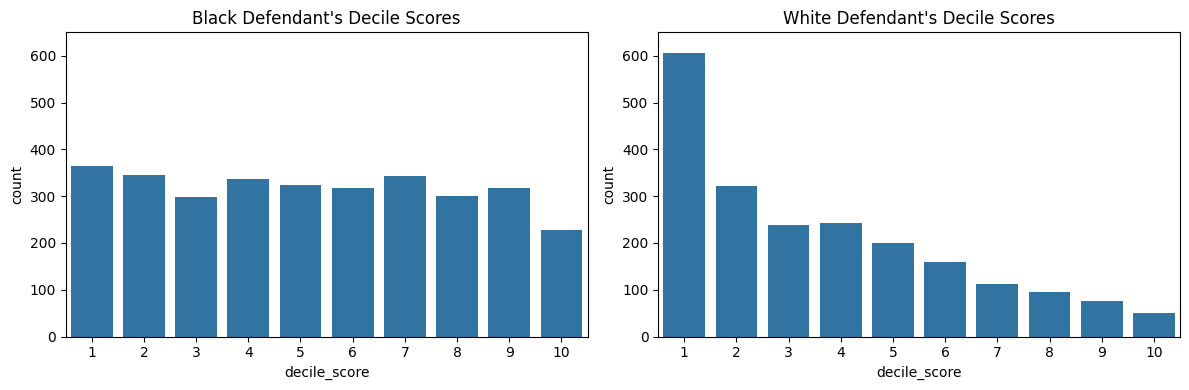

In [19]:
# Plot decile scores by race
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# We will use countplot to show the distribution of decile scores for African-American defendants, ordered by the unique decile scores in the dataset.
sns.countplot(x='decile_score', data=df[df['race']=='African-American'], ax=axes[0], order=sorted(df['decile_score'].unique())) 
axes[0].set_title("Black Defendant's Decile Scores") # We will set the title of the first plot to "Black Defendant's Decile Scores" to match the R code.
axes[0].set_ylim(0, 650) # We will set the y-axis limit to 650 to match the R code and ensure the plots are comparable.
# We will use countplot to show the distribution of decile scores for Caucasian defendants, ordered by the unique decile scores in the dataset.
sns.countplot(x='decile_score', data=df[df['race']=='Caucasian'], ax=axes[1], order=sorted(df['decile_score'].unique())) 
axes[1].set_title("White Defendant's Decile Scores") # We will set the title of the second plot to "White Defendant's Decile Scores" to match the R code.
axes[1].set_ylim(0, 650) # We will set the y-axis limit to 650 to match the R code and ensure the plots are comparable.
plt.tight_layout() # We will use tight_layout to adjust the spacing between the subplots for better appearance.
plt.show() # We will use plt.show() to display the plots.

The graphs show the distribution of decile scores for Black and White defendants. We can see that there are more Black defendants with higher decile scores compared to White defendants, which may indicate a potential bias in the predictive model. This disparity in decile scores could contribute to differences in the predicted risk of recidivism between the two racial groups, highlighting the importance of analyzing and addressing potential biases in predictive models used in the criminal justice system. Hence, it is crucial to evaluate the performance of the predictive model across different racial groups to ensure fairness and mitigate any potential biases in the predictions.

In [20]:
# Crosstab decile_score and race
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


The table above shows the count of defendants in each decile score category for each racial group. It allows us to see the distribution of decile scores across different

In [21]:
pd.crosstab(df["decile_score"], df["score_factor"])

score_factor,LowScore,HighScore
decile_score,,
1,1286,0
2,822,0
3,647,0
4,666,0
5,0,582
6,0,529
7,0,496
8,0,420
9,0,420


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [22]:
# Ensure categorical dtype FIRST
df['age_cat'] = df['age_cat'].astype('category')
df['race'] = df['race'].astype('category')

# Create factors with the same reference levels as the R code (Low for score_text
df['score_factor'] = (df['score_text'] != 'Low').astype(int)
df['gender_factor'] = (df['sex'] == 'Female').astype(int)
# Reorder categories to match R's reference levels
df['age_factor'] = df['age_cat'].cat.reorder_categories(
    ['25 - 45', 'Greater than 45', 'Less than 25'],
    ordered=True
)
# Reorder race categories to match R's reference levels
df['race_factor'] = df['race'].cat.reorder_categories(
    ['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'],
    ordered=True
)

# Model matrix
from patsy import dmatrices
# This formula matches the R code's model specification, with the same reference levels for factors
y, X = dmatrices(
    'score_factor ~ gender_factor + age_factor + race_factor + priors_count + C(c_charge_degree) + two_year_recid',
    data=df,
    return_type='dataframe'
)
# The original R code used glm() with a binomial family, which corresponds to logistic regression. In Python, we can use statsmodels' Logit for this purpose.
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        11:55:48   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

This summary shows the results of the logistic regression model, including the coefficients for each predictor variable, their standard errors, z-values, and p-values. The significance of each predictor can be assessed based on the p-values, and the direction and magnitude of the relationship between each predictor and the outcome variable (score_factor) can be interpreted from the coefficients. This analysis helps us understand which factors are associated with higher or lower risk scores in the COMPAS dataset. Therefore, we can identify potential biases in the model's predictions based on the significance and direction of the coefficients, especially for the race_factor variable, which can indicate if there are disparities in the risk scores assigned to different racial groups.

Note that the output from R's glm summary, which includes deviance, AIC, and Fisher Scoring iterations specifically for R environment. However in Python, statsmodels' Logit model summary does not display these exact lines by default. Instead, it shows:

- Log-Likelihood (analogous to deviance)
- AIC and BIC
- Convergence information (but not "Number of Fisher Scoring iterations" in the same way)
- Degrees of freedom

To see deviance and number of iterations in Python, we can access them as follows:

- Null deviance: $-2 \times$ log-likelihood of the intercept-only model (not shown by default, but can be computed)
- Residual deviance: $-2 \times$ log-likelihood of the fitted model (see result.llf)
- AIC: shown in result.summary()
- Number of iterations: result.mle_retvals['iterations'] (if available)

Python's statsmodels focuses on likelihood and information criteria, not the exact deviance output as in R.

In [23]:
# Additional model diagnostics to match R's glm output
# Null model (intercept only) for null deviance
try:
    y_null, X_null = dmatrices('score_factor ~ 1', data=df, return_type='dataframe')
    null_model = sm.Logit(y_null, X_null)
    null_result = null_model.fit(disp=0)
    null_deviance = -2 * null_result.llf
except PerfectSeparationError:
    null_deviance = np.nan

# Residual deviance from fitted model
residual_deviance = -2 * result.llf

# Degrees of freedom
n_obs = y.shape[0]
df_null = n_obs - 1
df_resid = n_obs - X.shape[1]

# AIC (already in result.aic)
aic = result.aic

# Number of iterations
iterations = result.mle_retvals.get('iterations', 'N/A') if hasattr(result, 'mle_retvals') else 'N/A'

print(f"Null deviance: {null_deviance:.1f}  on {df_null}  degrees of freedom")
print(f"Residual deviance: {residual_deviance:.1f}  on {df_resid}  degrees of freedom")
print(f"AIC: {aic:.1f}")
print(f"Number of Fisher Scoring iterations: {iterations}")

Null deviance: 8483.3  on 6171  degrees of freedom
Residual deviance: 6168.4  on 6160  degrees of freedom
AIC: 6192.4
Number of Fisher Scoring iterations: 6


Compare Black defendants with White defendants after correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [24]:
# Calculate odds ratio for Black vs White
control = np.exp(result.params['Intercept']) / (1 + np.exp(result.params['Intercept']))
black_coef = [k for k in result.params.keys() if 'race_factor[T.African-American]' in k][0]
odds_black = np.exp(result.params[black_coef]) / (1 - control + (control * np.exp(result.params[black_coef])))
print(f'Black vs White odds ratio: {odds_black:.6f}')

Black vs White odds ratio: 1.452837


Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [25]:
# Calculate odds ratio for Female vs Male
female_coef = [k for k in result.params.keys() if 'gender_factor' in k][0]
odds_female = np.exp(result.params[female_coef]) / (1 - control + (control * np.exp(result.params[female_coef])))
print(f'Female vs Male odds ratio: {odds_female:.6f}')

Female vs Male odds ratio: 1.194795


Women are 19.4% more likely than men to get a higher score.

In [26]:
# Calculate odds ratio for Less than 25 vs 25-45
age_coef = [k for k in result.params.keys() if 'age_factor[T.Less than 25]' in k][0]
odds_young = np.exp(result.params[age_coef]) / (1 - control + (control * np.exp(result.params[age_coef])))
print(f'Under 25 vs 25-45 odds ratio: {odds_young:.6f}')

Under 25 vs 25-45 odds ratio: 2.496120


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [27]:
# Predict probabilities and classes
df['pred_prob'] = result.predict(X)
# We will create a new column 'pred_class' that contains the predicted class labels based on a threshold of 0.5. 
# We will map the boolean values to "No Recid" and "Recid" to match the R code's factor levels, and set it as a categorical variable with the same order as the R code.
df["pred_class"] = (
    (df["pred_prob"] >= 0.5) # Predicted class (threshold = 0.5)
    .map({False: "No Recid", True: "Recid"})  # Map predicted class to labels and set as categorical with the same order as R's factor levels
    .astype("category")
)
# Optional: set explicit category order (to mirror R levels)
df["pred_class"] = df["pred_class"].cat.set_categories(["No Recid", "Recid"])

The following code calculates the confusion matrix and performance metrics separately for Black and White defendants to analyze potential disparities in the model's predictions based on race. Hence, we filter the DataFrame for each racial group and then compute the confusion matrix and metrics for each group separately. This allow us to compare the model's performance across different racial groups and identify any potential biases in the predictions.

In [28]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

# Confusion matrix
cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(cm)

# Extract values (same layout as R)
TP = cm.loc["Recid", 1]
TN = cm.loc["No Recid", 0]
FP = cm.loc["Recid", 0]
FN = cm.loc["No Recid", 1]

n = cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


We calculate the confusion matrix and performance metrics separately for Black and White defendants to analyze potential disparities in the model's predictions based on race. We loop through each race category, compute the confusion matrix for that subgroup, and then calculate the performance metrics (Accuracy, Precision, Recall, FPR, FNR) for each race. Finally, we compile these metrics into a DataFrame for easy comparison.   


In [29]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

# Create actual and predicted numeric columns
df_metrics = df.copy()
df_metrics["actual"] = df_metrics["two_year_recid"].astype(int)
df_metrics["pred"] = (df_metrics["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df_metrics
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Compute metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by descending n
race_metrics = race_metrics.sort_values(by="n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In the above, we can see that the confusion matrix and metrics for each race group are now calculated and displayed in a DataFrame format, allowing for easy comparison across groups. The metrics include Accuracy, Precision, Recall, False Positive Rate (FPR), and False Negative Rate (FNR), which are essential for evaluating the performance of the predictive model across different racial groups.


Below here we calculate the disparity in False Positive Rate (FPR) and False Negative Rate (FNR) for each racial group compared to the Caucasian group. We will compute the difference in FPR and FNR for each racial group relative to the Caucasian group, which will allow us to identify any disparities in the model's performance across different racial groups. This analysis is crucial for understanding potential biases in the predictive model and ensuring fairness in its predictions.  



In [30]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

# Select relevant columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [31]:
# Python equivalent of the R code to load and count rows in the violent recidivism dataset
violent_url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv'
violent_raw_data = pd.read_csv(violent_url)
violent_raw_data.shape

(4743, 54)

Ths code below selects relevant columns, applies the same filters as before, and creates a new DataFrame for the violent recidivism dataset. The filters ensure that we only include records where the days between screening and arrest are within 30 days, the recidivism status is known, the charge degree is not 'O', and the score text is not 'N/A'. After applying these filters, we print the number of rows in the resulting DataFrame to see how many records are included in the violent recidivism analysis.


In [32]:
# Python equivalent of the R code above for violent recidivism data
violent_cols = ["age", "c_charge_degree", "race", "age_cat", "score_text", "sex", "priors_count", "days_b_screening_arrest", "decile_score", "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"]
violent_df = prepare_compas_subset(violent_raw_data)
violent_df.head()


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [33]:
# Count of defendants in each age category for violent recidivism dataset
violent_df['age_cat'].value_counts() # this shows the count of defendants in each age category for the violent recidivism dataset

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

In [34]:
# Python equivalent of R's summary(violent_df$race)
violent_df['race'].value_counts() # Show count of defendants in each racial category for the violent recidivism dataset

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

In [35]:
# This shows the count of defendants in each score category (Low, Medium, High) for the violent recidivism dataset
violent_df['score_text'].value_counts()

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64

In [36]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100
# Calculate percentage of recidivists in the violent recidivism dataset
recid_percent = (violent_df[violent_df['two_year_recid'] == 1].shape[0] / violent_df.shape[0]) * 100
print(f'Percent recidivists: {recid_percent:.2f}%')

Percent recidivists: 45.51%


In [37]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1))
recid_count = violent_df[violent_df['two_year_recid'] == 1].shape[0]
print('Number of recidivists:', recid_count)

Number of recidivists: 2809


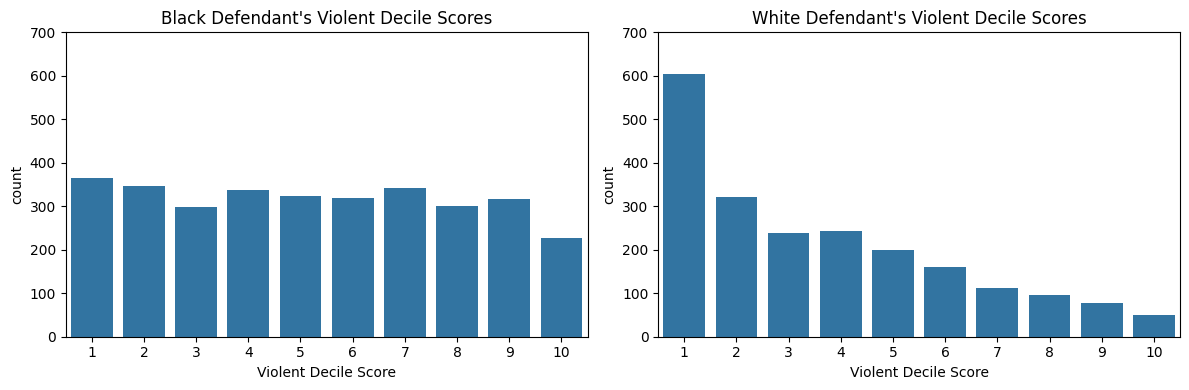

In [38]:
# Python equivalent of the R ggplot2 code for side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Black defendants
sns.countplot(x='decile_score', data=violent_df[violent_df['race'] == 'African-American'], ax=axes[0], order=sorted(violent_df['decile_score'].unique()))
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Violent Decile Score")
axes[0].set_ylim(0, 700)

# White defendants
sns.countplot(x='decile_score', data=violent_df[violent_df['race'] == 'Caucasian'], ax=axes[1], order=sorted(violent_df['decile_score'].unique()))
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Violent Decile Score")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

We can see for the graph that the distribution of violent decile scores is similar for Black and White defendants, with a higher concentration of scores in the lower deciles (indicating lower risk) for both groups. However, there may be a slightly higher proportion of Black defendants in the higher deciles compared to White defendants, which could suggest some disparities in the risk assessment. Hence, while the overall distribution is similar, there may be some differences in how the scores are assigned across racial groups that could warrant further investigation.

The following code calculates the null deviance, residual deviance, AIC, and number of iterations for the logistic regression model on the violent recidivism dataset, similar to the R glm output.

In [39]:
# Python equivalent of the R code for factor creation and logistic regression
# Set up categorical variables with reference levels
violent_df['crime_factor'] = violent_df['c_charge_degree'].astype('category')
violent_df['age_factor'] = violent_df['age_cat'].astype('category')
violent_df['age_factor'] = violent_df['age_factor'].cat.reorder_categories([
    violent_df['age_factor'].cat.categories[0],  # R's ref=1 (first level)
    *[cat for cat in violent_df['age_factor'].cat.categories if cat != violent_df['age_factor'].cat.categories[0]]
], ordered=True)
violent_df['race_factor'] = violent_df['race'].astype('category')
violent_df['race_factor'] = violent_df['race_factor'].cat.reorder_categories([
    'Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other'
], ordered=True)
violent_df['gender_factor'] = violent_df['sex'].astype('category')
violent_df['gender_factor'] = violent_df['gender_factor'].cat.reorder_categories(['Male', 'Female'], ordered=True)
violent_df['score_factor'] = pd.Categorical(
    ['HighScore' if val else 'LowScore' for val in (violent_df['score_text'] != 'Low')],
    categories=['LowScore', 'HighScore'],
    ordered=True
)
# Logistic regression model
formula = 'score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid'
y, X = dmatrices(formula, data=violent_df, return_type='dataframe')
y = y.iloc[:, 0]  # Convert y to 1D Series for Logit
model = sm.Logit(y, X) # Fit the model and print summary
result = model.fit() # Fit the logistic regression model
print(result.summary()) # Print the summary of the fitted model


Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                             Logit Regression Results                             
Dep. Variable:     score_factor[LowScore]   No. Observations:                 6172
Model:                              Logit   Df Residuals:                     6160
Method:                               MLE   Df Model:                           11
Date:                    Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                            11:55:49   Log-Likelihood:                -3084.2
converged:                           True   LL-Null:                       -4241.7
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         

This show that the difference in deviance between the null model and the fitted model is statistically significant, indicating that the predictors in the model provide a better fit to the data than the null model. Hence, the model is a significant improvement over the null model, suggesting that the included predictors are relevant for explaining the variation in the outcome variable (score_factor).

The violent score overpredicts recidivism for black defendants by 77.3% compared to white defendants.

In [40]:
# Python equivalent of the R code above
control = np.exp(-2.24274) / (1 + np.exp(-2.24274))
result = np.exp(0.65893) / (1 - control + (control * np.exp(0.65893)))
print(result)

1.7739209589164604


Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants.

In [41]:
# Python equivalent of the R code above
result_under25 = np.exp(3.14591) / (1 - control + (control * np.exp(3.14591)))
print(result_under25)

7.414239863565466


## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [42]:
# Load data
# Read the CSV
# data = pd.read_csv("./cox-parsed.csv")
data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv")

# Apply filters and create the same categorical reference levels used in the R workflow
data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()
race_categories = ["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"]
data["race_factor"] = pd.Categorical(data["race"], categories=["Caucasian"] + [r for r in race_categories if r != "Caucasian"], ordered=False)
score_levels = sorted(data["score_text"].dropna().unique())
if len(score_levels) >= 2:
    score_levels = [score_levels[1]] + [s for s in score_levels if s != score_levels[1]]
data["score_factor"] = pd.Categorical(data["score_text"], categories=score_levels, ordered=False)

grp = data.drop_duplicates(subset="id")
print(len(grp))


10325


In [43]:
# Equivalent of summary(grp$score_factor) in Python
grp['score_factor'].value_counts() # This shows the count of defendants in each score category (Low, Medium, High) in the grp DataFrame

score_factor
Low       5751
Medium    2611
High      1952
Name: count, dtype: int64

In [44]:
# Equivalent of summary(grp$race_factor) in Python
grp['race_factor'].value_counts() # This shows the count of defendants in each racial category in the grp DataFrame

race_factor
African-American    5150
Caucasian           3576
Hispanic             944
Other                572
Asian                 51
Native American       32
Name: count, dtype: int64

In [45]:
# Fit the baseline Cox model: Surv(start, end, event, type="counting") ~ score_factor
ctv, baseline_cox_df = fit_time_varying_cox(
    data,
    columns=["id", "start", "end", "event", "score_factor"],
    dummy_cols=["score_factor"],
)
ctv.print_summary()


<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30305.85
  time fit was run = 2026-04-30 15:55:50 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.25      3.49      0.04            1.17            1.33                3.22                3.78
score_factor_Medium  0.80      2.22      0.04            0.72            0.88                2.05                2.40

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 30.14 <0.005    660.70
score_factor_Medium    0.00 19.53 <0.005    279.75
---
Partial AIC = 60615.71
log-likelihood ratio test = 942.82 on 2 df
-log2(p) of ll-ratio test = 680.10

People placed in the High category are 3.5 times as likely to recidivate, and the COMPAS system's concordance 63.6%. This is lower than the accuracy quoted in the Northpoint study of 68%.

In [46]:
# Fit the decile-score Cox model: Surv(start, end, event, type="counting") ~ decile_score
ctv, decile_f = fit_time_varying_cox(
    data,
    columns=["id", "start", "end", "event", "decile_score"],
)
ctv.print_summary()


<lifelines.CoxTimeVaryingFitter: fitted with 13356 periods, 10325 subjects, 3471 events>
         event col = 'event'
number of subjects = 10325
 number of periods = 13356
  number of events = 3471
partial log-likelihood = -30243.34
  time fit was run = 2026-04-30 15:55:53 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.63 <0.005    821.24
---
Partial AIC = 60488.67
log-likelihood ratio test = 1113.55 on 1 df
-log2(p) of ll-ratio test = 808.64

COMPAS's decile scores are a bit more accurate at 66%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [47]:
# Fit the interaction model: Surv(start, end, event, type="counting") ~ race_factor + score_factor + race_factor * score_factor
ctv, f2 = fit_time_varying_cox(
    data,
    columns=["id", "start", "end", "event", "race_factor", "score_factor"],
    formula="race_factor + score_factor + race_factor:score_factor",
)
ctv.print_summary()


<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30280.41
  time fit was run = 2026-04-30 15:55:55 UTC

---
                                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                               
race_factor[T.African-American]                         0.28      1.32      0.06            0.16            0.40                1.17                1.49
race_factor[T.Asian]                                   -0.78      0.46      0.50           -1.76            0.21                0.17                1.23
race_factor[T.Hispanic]                                -0.06      0.94      0.10           -0.25            0.13                0.78                1.13
race_factor[T.Native American]                         -1.25      0.29      1.00           -3.22            0.71                0.04                2.03
race_factor[T.Other]                                    0.01      1.01      0.11           -0.20            0.23                0.82                1.26
score_factor[T.High]                                    1.28      3.61      0.08            1.12            1.45                3.06                4.25
score_factor[T.Medium]                                  0.84      2.32      0.07            0.70            0.98                2.02                2.67
race_factor[T.African-American]:score_factor[T.High]   -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
race_factor[T.Asian]:score_factor[T.High]               1.32      3.73      0.77           -0.19            2.82                0.83               16.80
race_factor[T.Hispanic]:score_factor[T.High]           -0.12      0.89      0.20           -0.51            0.27                0.60                1.31
race_factor[T.Native American]:score_factor[T.High]     1.96      7.07      1.08           -0.17            4.08                0.85               59.09
race_factor[T.Other]:score_factor[T.High]               0.41      1.51      0.26           -0.09            0.92                0.91                2.52
race_factor[T.African-American]:score_factor[T.Medium] -0.17      0.84      0.09           -0.35            0.01                0.70                1.01
race_factor[T.Asian]:score_factor[T.Medium]             0.99      2.68      0.71           -0.41            2.38                0.67               10.80
race_factor[T.Hispanic]:score_factor[T.Medium]          0.07      1.07      0.16           -0.26            0.39                0.77                1.47
race_factor[T.Native American]:score_factor[T.Medium]   1.39      4.01      1.12           -0.81            3.59                0.45               36.07
race_factor[T.Other]:score_factor[T.Medium]            -0.33      0.72      0.23           -0.79            0.12                0.45                1.13

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  4.59 <0.005     17.75
race_factor[T.Asian]                                      0.00 -1.55   0.12      3.04
race_factor[T.Hispanic]                                   0.00 -0.66   0.51      0.97
race_factor[T.Native American]                            0.00 -1.25   0.21      2.25
race_factor[T.Other]                                      0.00  0.13   0.90      0.16
score_factor[T.High]                                      0.00 15.36 <0.005    174.41
score_factor[T.Medium]                                    0.00 11.80 <0.005    104.36
race_factor[T.African-American]:sco

The interaction term shows a similar disparity as the logistic regression above.

High risk white defendants are 3.61 more likely than low risk white defendants, while High risk black defendants are 2.99 more likely than low.

In [48]:
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286-0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


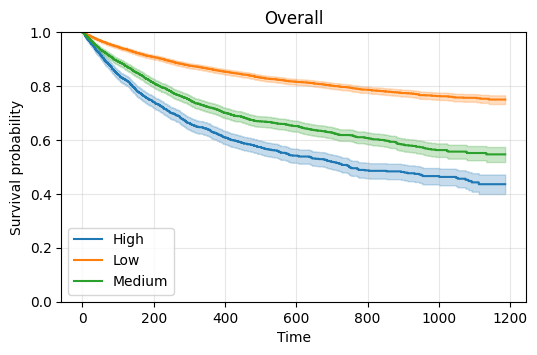

In [49]:
# Collapse to one record per subject (like your grp earlier)
df = prepare_km_frame(data)
plot_km_grouped(df, "Overall")


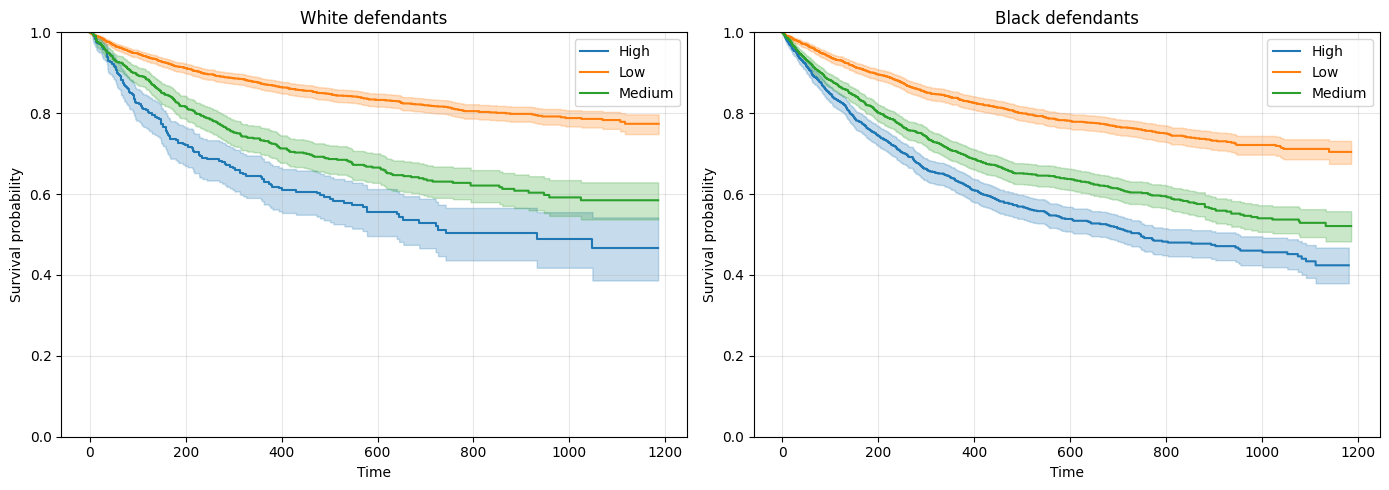

In [50]:
# Prepare base dataframe (one row per subject)
df = prepare_km_frame(data, extra_cols=["race"])

# Subsets
white = df[df["race"] == "Caucasian"].copy()
black = df[df["race"] == "African-American"].copy()

# Create side-by-side plots (equivalent to grid.arrange)
side_by_side_km(white, "White defendants", black, "Black defendants")


In [51]:
# Prepare data
km_overall = prepare_km_frame(data)
time_point = 730
print_km_summary_rstyle(km_overall, "data", time_point=time_point)


Call: survfit(formula = f, data = data)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    3.51e+02    7.40e+02    1.95e+03    8.63e+02    5.07e-01
        std.err    lower 95% CI    upper 95% CI
      1.40e-02    4.80e-01    5.34e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.35e+03    1.03e+03    5.75e+03    2.38e+03    7.97e-01
        std.err    lower 95% CI    upper 95% CI
      5.76e-03    7.85e-01    8.08e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    7.36e+02    8.27e+02    2.61e+03    1.05e+03    6.19e-01
        std.err    lower 95% CI    upper 95% CI
      1.09e-02    5.97e-01    6.39e-01



In [52]:
# Prepare data (one row per subject)
df = prepare_km_frame(data, extra_cols=["race"])
black = df[df["race"] == "African-American"].copy()
print_km_summary_rstyle(black, "black", time_point=730)


Call: survfit(formula = f, data = black)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.56e+02    5.41e+02    1.42e+03    6.25e+02    5.03e-01
        std.err    lower 95% CI    upper 95% CI
      1.64e-02    4.71e-01    5.35e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    8.44e+02    4.57e+02    2.18e+03    8.85e+02    7.63e-01
        std.err    lower 95% CI    upper 95% CI
      9.89e-03    7.43e-01    7.82e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    4.39e+02    5.12e+02    1.54e+03    5.94e+02    6.04e-01
        std.err    lower 95% CI    upper 95% CI
      1.42e-02    5.76e-01    6.31e-01



In [53]:
# Prepare data (one row per subject)
df = prepare_km_frame(data, extra_cols=["race"])
white = df[df["race"] == "Caucasian"].copy()
print_km_summary_rstyle(white, "white", time_point=730)

Call: survfit(formula = f, data = white)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    5.80e+01    1.45e+02    3.97e+02    1.94e+02    5.12e-01
        std.err    lower 95% CI    upper 95% CI
      3.24e-02    4.47e-01    5.74e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    1.00e+03    3.85e+02    2.37e+03    9.86e+02    8.16e-01
        std.err    lower 95% CI    upper 95% CI
      8.62e-03    7.99e-01    8.33e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.15e+02    2.42e+02    8.00e+02    3.43e+02    6.31e-01
        std.err    lower 95% CI    upper 95% CI
      1.98e-02    5.91e-01    6.68e-01



Race specific models have similar concordance values.

In [54]:
# Build white subset and fit the race-specific Cox model
white = data[data["race"] == "Caucasian"].copy()
white_model, white_model_df = fit_time_varying_cox(
    white,
    columns=["id", "start", "end", "event", "score_factor"],
    formula="score_factor",
)
white_model.print_summary()


<lifelines.CoxTimeVaryingFitter: fitted with 4564 periods, 3569 subjects, 1023 events>
         event col = 'event'
number of subjects = 3569
 number of periods = 4564
  number of events = 1023
partial log-likelihood = -7919.63
  time fit was run = 2026-04-30 15:56:04 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.High]    1.28      3.58      0.08            1.11            1.44                3.04                4.22
score_factor[T.Medium]  0.84      2.32      0.07            0.70            0.98                2.01                2.66

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.High]      0.00 15.26 <0.005    172.18
score_factor[T.Medium]    0.00 11.75 <0.005    103.54
---
Partial AIC = 15843.27
log-likelihood ratio test = 262.78 on 2 df
-log2(p) of ll-ratio test = 189.56

Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [55]:
# Load the violent recidivism time-to-event data and keep the same factor coding as in the R workflow
violent_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv")
violent_data = violent_data[(violent_data["score_text"] != "N/A") & (violent_data["end"] > violent_data["start"])].copy()
violent_data["race_factor"] = pd.Categorical(
    violent_data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
    ordered=False,
)
violent_score_levels = sorted(violent_data["score_text"].dropna().unique().tolist())
if len(violent_score_levels) >= 2:
    violent_score_levels = [violent_score_levels[1]] + [x for x in violent_score_levels if x != violent_score_levels[1]]
violent_data["score_factor"] = pd.Categorical(violent_data["score_text"], categories=violent_score_levels, ordered=False)

vmodel, violent_baseline_df = fit_time_varying_cox(
    violent_data,
    columns=["id", "start", "end", "event", "score_factor"],
    formula="score_factor",
)
vgrp = violent_data.drop_duplicates(subset="id")
print(f"[1] {len(vgrp)}")
print_cox_summary_rstyle(vmodel, violent_baseline_df, "vf, data = violent_data")


[1] 10999
Call:
coxph(formula = vf, data = violent_data)

  n= 18178, number of events= 818

                              coef  exp(coef)  se(coef)        z   Pr(>|z|)
score_factor[T.High]       1.38311    3.98729   0.08410   16.447     <2e-16 ***
score_factor[T.Medium]     0.80350    2.23334   0.08699    9.236     <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                         exp(coef)  exp(-coef)  lower .95  upper .95
score_factor[T.High]         3.987      0.2508      3.381      4.702
score_factor[T.Medium]       2.233      0.4478      1.883      2.649

Concordance= NA (se = NA )
Likelihood ratio test= 270.6  on 2 df,   p=1.7e-59
Wald test            = 355.8  on 2 df,   p=5.46e-78
Score (logrank) test = 270.6  on 2 df,   p=1.7e-59


In this case, there isn't a significant coefficient on African American's with High Scores.

In [ ]:
# Now fit the model with interaction
vmodel, vf2_df = fit_time_varying_cox(
    violent_data,
    columns=["id", "start", "end", "event", "race_factor", "score_factor"],
    formula="race_factor + race_factor:score_factor",
)
print_cox_summary_rstyle(vmodel, vf2_df, "vf2, data = violent_data")


In [ ]:
# Now fit the model for just African-American defendants (like your vf3)
black_data = violent_data[violent_data["race"] == "African-American"].copy()
vmodel, vf_black_df = fit_time_varying_cox(
    black_data,
    columns=["id", "start", "end", "event", "score_factor"],
    formula="score_factor",
)
print_cox_summary_rstyle(vmodel, vf_black_df, 'vf, data = filter(violent_data, race == "African-American")')

Call:
coxph(formula = vf, data = filter(violent_data, race == "African-American"))

  n= 9712, number of events= 495

                              coef  exp(coef)  se(coef)        z   Pr(>|z|)
score_factor[T.High]       1.24115    3.45960   0.11396   10.891     <2e-16 ***
score_factor[T.Medium]     0.75890    2.13592   0.12018    6.315   2.71e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                         exp(coef)  exp(-coef)  lower .95  upper .95
score_factor[T.High]         3.460      0.2891      2.767      4.325
score_factor[T.Medium]       2.136      0.4682      1.688      2.703

Concordance= NA (se = NA )
Likelihood ratio test= 127.5  on 2 df,   p=2.1e-28
Wald test            = 158.5  on 2 df,   p=3.84e-35
Score (logrank) test = 127.5  on 2 df,   p=2.1e-28


In [ ]:
# Fit the model for just Caucasian defendants
white_data = violent_data[violent_data["race"] == "Caucasian"].copy()
vmodel, vf_white_df = fit_time_varying_cox(
    white_data,
    columns=["id", "start", "end", "event", "score_factor"],
    formula="score_factor",
)
print_cox_summary_rstyle(vmodel, vf_white_df, 'vf, data = filter(violent_data, race == "Caucasian")')


Call:
coxph(formula = vf, data = filter(violent_data, race == "Caucasian"))

  n= 6041, number of events= 221

                              coef  exp(coef)  se(coef)        z   Pr(>|z|)
score_factor[T.High]       1.25016    3.49089   0.17202    7.267   3.67e-13 ***
score_factor[T.Medium]     0.63097    1.87943   0.15828    3.986   6.71e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                         exp(coef)  exp(-coef)  lower .95  upper .95
score_factor[T.High]         3.491      0.2865      2.492      4.891
score_factor[T.Medium]       1.879      0.5321      1.378      2.563

Concordance= NA (se = NA )
Likelihood ratio test= 49.6  on 2 df,   p=1.67e-11
Wald test            = 68.7  on 2 df,   p=1.2e-15
Score (logrank) test = 49.6  on 2 df,   p=1.67e-11


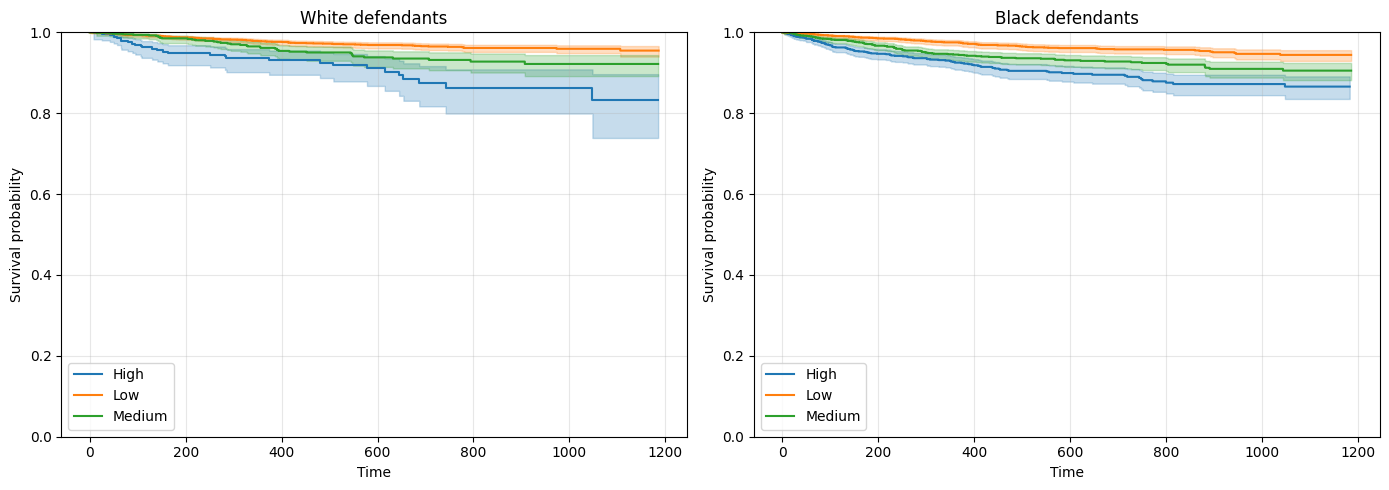

In [ ]:
# Prepare white and black violent-recidivism KM curves and display them side by side
violent_km = prepare_km_frame(violent_data, extra_cols=["race"])
white = violent_km[violent_km["race"] == "Caucasian"].copy()
black = violent_km[violent_km["race"] == "African-American"].copy()
side_by_side_km(white, "White defendants", black, "Black defendants")


## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [ ]:
# Load the CSV from URL
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv"
people_df = pd.read_csv(url)

people_df["end"] = pd.to_numeric(people_df["end"], errors="coerce")
people_df["event"] = pd.to_numeric(people_df["event"], errors="coerce")
people_df["lifetime"] = people_df["end"]
people_df["recidivist"] = people_df["event"] == 1
people_df["score_valid"] = people_df["score_text"] != "N/A"

people = []
for _, row in people_df.iterrows():
    person = type("PersonRow", (), row.to_dict())()
    person.lifetime = row["lifetime"]
    person.recidivist = row["recidivist"]
    person.score_valid = row["score_valid"]
    person.valid = True
    people.append(person)


In [ ]:
# If you previously installed the wrong package, optionally remove it:
# !pip uninstall -y truth_tables

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/truth_tables.py",
    "truth_tables.py"
)

import importlib.util
spec = importlib.util.spec_from_file_location("truth_tables_local", "truth_tables.py")
truth_tables_local = importlib.util.module_from_spec(spec)
spec.loader.exec_module(truth_tables_local)

PeekyReader = truth_tables_local.PeekyReader
Person = truth_tables_local.Person
table = truth_tables_local.table
is_race = truth_tables_local.is_race
count = truth_tables_local.count
vtable = truth_tables_local.vtable
hightable = truth_tables_local.hightable
vhightable = truth_tables_local.vhightable

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv",
    "cox-parsed.csv"
)

people = []
with open("cox-parsed.csv", newline="", encoding="utf-8") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                people.append(p)
    except StopIteration:
        pass

pop = list(filter(lambda i: ((i.recidivist is True and i.lifetime <= 730) or i.lifetime > 730), filter(lambda x: x.score_valid, people)))
recid = list(filter(lambda i: i.recidivist is True and i.lifetime <= 730, pop))
rset = set(recid)
surv = [i for i in pop if i not in rset]


In [ ]:
print("All defendants")
table(list(recid), list(surv))

All defendants
           	Low	High
Survived   	2681	1282	0.55
Recidivated	1216	2035	0.45
Total: 7214.00
False positive rate: 32.35
False negative rate: 37.40
Specificity: 0.68
Sensitivity: 0.63
Prevalence: 0.45
PPV: 0.61
NPV: 0.69
LR+: 1.94
LR-: 0.55


In [ ]:
print("Total pop: %i" % (2681 + 1282 + 1216 + 2035))

Total pop: 7214


In [ ]:
import statistics
print("Average followup time %.2f (sd %.2f)" % (statistics.mean(map(lambda i: i.lifetime, pop)),
                                                statistics.stdev(map(lambda i: i.lifetime, pop))))
print("Median followup time %i" % (statistics.median(map(lambda i: i.lifetime, pop))))

Average followup time 622.87 (sd 392.19)
Median followup time 766


### Overall, the false positive rate is 32.35%.

In [ ]:
print("Black defendants")
is_afam = is_race("African-American")
table(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

Black defendants
           	Low	High
Survived   	990	805	0.49
Recidivated	532	1369	0.51
Total: 3696.00
False positive rate: 44.85
False negative rate: 27.99
Specificity: 0.55
Sensitivity: 0.72
Prevalence: 0.51
PPV: 0.63
NPV: 0.65
LR+: 1.61
LR-: 0.51


That number is higher for African Americans at 44.85%.

In [ ]:
print("White defendants")
is_white = is_race("Caucasian")
table(list(filter(is_white, recid)), list(filter(is_white, surv)))

White defendants
           	Low	High
Survived   	1139	349	0.61
Recidivated	461	505	0.39
Total: 2454.00
False positive rate: 23.45
False negative rate: 47.72
Specificity: 0.77
Sensitivity: 0.52
Prevalence: 0.39
PPV: 0.59
NPV: 0.71
LR+: 2.23
LR-: 0.62


And lower for whites at 23.45%.

In [ ]:
44.85 / 23.45

1.9125799573560769

Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

[link text](https://) COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [ ]:
47.72 / 27.99

1.7048946052161487

In [ ]:
hightable(list(filter(is_white, recid)), list(filter(is_white, surv)))

           	Low	High
Survived   	1407	81	0.61
Recidivated	771	195	0.39
Total: 2454.00
False positive rate: 5.44
False negative rate: 79.81
Specificity: 0.95
Sensitivity: 0.20
Prevalence: 0.39
PPV: 0.71
NPV: 0.65
LR+: 3.71
LR-: 0.84


In [ ]:
hightable(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

           	Low	High
Survived   	1511	284	0.49
Recidivated	1160	741	0.51
Total: 3696.00
False positive rate: 15.82
False negative rate: 61.02
Specificity: 0.84
Sensitivity: 0.39
Prevalence: 0.51
PPV: 0.72
NPV: 0.57
LR+: 2.46
LR-: 0.72


## Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [ ]:
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv",
    "cox-violent-parsed.csv"
)

vpeople = []
with open("cox-violent-parsed.csv", newline="", encoding="utf-8") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                vpeople.append(p)
    except StopIteration:
        pass

vpop = list(filter(lambda i: ((i.violent_recidivist is True and i.lifetime <= 730) or i.lifetime > 730), filter(lambda x: x.vscore_valid, vpeople)))
vrecid = list(filter(lambda i: i.violent_recidivist is True and i.lifetime <= 730, vpop))
vrset = set(vrecid)
vsurv = [i for i in vpop if i not in vrset]


In [ ]:
print("All defendants")
vtable(list(vrecid), list(vsurv))

All defendants
           	Low	High
Survived   	4121	1597	0.89
Recidivated	347	389	0.11
Total: 6454.00
False positive rate: 27.93
False negative rate: 47.15
Specificity: 0.72
Sensitivity: 0.53
Prevalence: 0.11
PPV: 0.20
NPV: 0.92
LR+: 1.89
LR-: 0.65


Even moreso for Black defendants.

In [ ]:
print("Black defendants")
is_afam = is_race("African-American")
vtable(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)))

Black defendants
           	Low	High
Survived   	1692	1043	0.86
Recidivated	170	273	0.14
Total: 3178.00
False positive rate: 38.14
False negative rate: 38.37
Specificity: 0.62
Sensitivity: 0.62
Prevalence: 0.14
PPV: 0.21
NPV: 0.91
LR+: 1.62
LR-: 0.62


In [ ]:
print("White defendants")
is_white = is_race("Caucasian")
vtable(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)))

White defendants
           	Low	High
Survived   	1679	380	0.91
Recidivated	129	77	0.09
Total: 2265.00
False positive rate: 18.46
False negative rate: 62.62
Specificity: 0.82
Sensitivity: 0.37
Prevalence: 0.09
PPV: 0.17
NPV: 0.93
LR+: 2.03
LR-: 0.77


Black defendants are twice as likely to be false positives for a Higher violent score than white defendants.

In [ ]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants.

In [ ]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

In [ ]:
# ---------------------------------------------------
# female <- filter(data, sex == "Female")
# male   <- filter(data, sex == "Male")
# ---------------------------------------------------
gender_km = prepare_km_frame(data, extra_cols=["sex"])
female = gender_km[gender_km["sex"] == "Female"].copy()
male = gender_km[gender_km["sex"] == "Male"].copy()

print("Male fit groups:", sorted(male["score_factor"].dropna().unique()))
print("Female fit groups:", sorted(female["score_factor"].dropna().unique()))


Male fit groups: ['High', 'Low', 'Medium']
Female fit groups: ['High', 'Low', 'Medium']


In [ ]:
# ---------------------------------------------------
# summary(male_fit, times=c(730))
# ---------------------------------------------------
print_km_summary_rstyle(male, "male", time_point=730)


Call: survfit(formula = f, data = male)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.98e+02    6.51e+02    1.67e+03    7.27e+02    4.98e-01
        std.err    lower 95% CI    upper 95% CI
      1.51e-02    4.68e-01    5.27e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    1.80e+03    8.65e+02    4.50e+03    1.83e+03    7.81e-01
        std.err    lower 95% CI    upper 95% CI
      6.74e-03    7.67e-01    7.94e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    5.53e+02    6.71e+02    2.03e+03    8.10e+02    5.99e-01
        std.err    lower 95% CI    upper 95% CI
      1.26e-02    5.73e-01    6.23e-01



In [ ]:
# ---------------------------------------------------
# summary(female_fit, times=c(730))
# ---------------------------------------------------
print_km_summary_rstyle(female, "female", time_point=730)


Call: survfit(formula = f, data = female)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    5.30e+01    8.90e+01    2.78e+02    1.36e+02    5.67e-01
        std.err    lower 95% CI    upper 95% CI
      3.76e-02    4.90e-01    6.37e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    5.46e+02    1.66e+02    1.25e+03    5.43e+02    8.54e-01
        std.err    lower 95% CI    upper 95% CI
      1.06e-02    8.32e-01    8.74e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    1.83e+02    1.56e+02    5.80e+02    2.41e+02    6.86e-01
        std.err    lower 95% CI    upper 95% CI
      2.14e-02    6.42e-01    7.26e-01



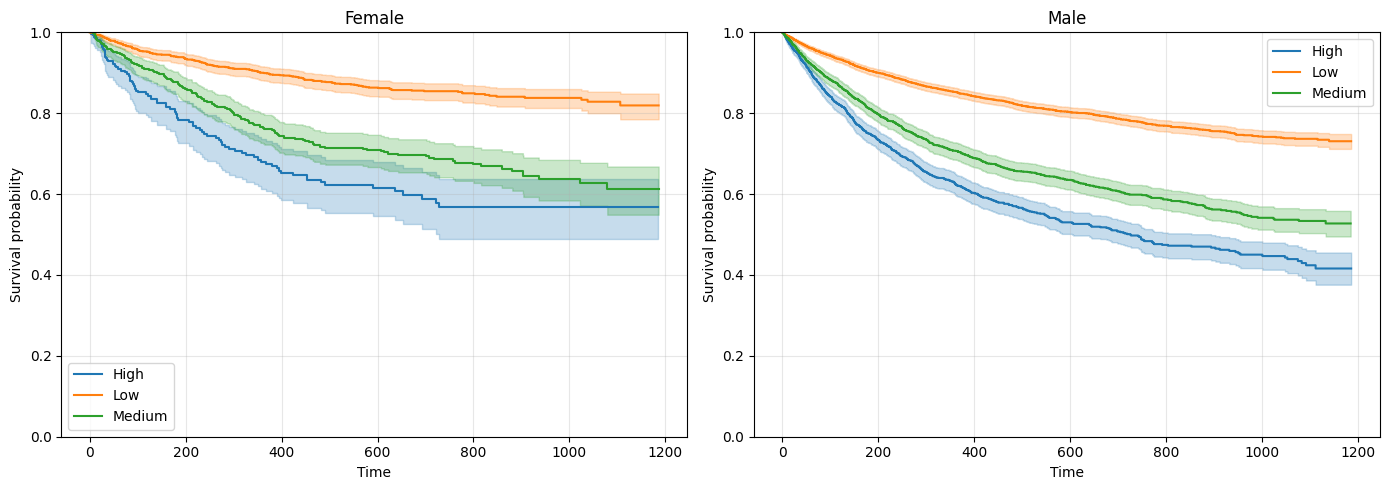

In [ ]:
# ---------------------------------------------------
# grid.arrange(plotty(female_fit, "Female"), plotty(male_fit, "Male"), ncol=2)
# ---------------------------------------------------
side_by_side_km(female, "Female", male, "Male")


As these plots show, the Compas score treats a High risk women the same as a Medium risk man.

## Assignment 2: COMPAS Explainability Pipeline

This is a placeholder for the code that would implement the explainability pipeline for the COMPAS model, which may include techniques like SHAP values, LIME, or other methods to interpret the model's predictions. And it allow us to understand which features are most influential in the model's decision-making process, and how they contribute to the predicted risk scores for defendants.


### Feature Engineering Seletion and Grouping

The feature engineering steps include by ensuring that the columns we want actually exist in the dataframe and are properly cleaned (no leading/trailing spaces, correct data types, etc.)


In [ ]:
# Shared model objects are defined once and reused in the explainability section below.
lr_pipeline = None
gbt_pipeline = None
black_idx = None
white_idx = None


### Step 1. Load + prepare COMPAS data

Preparing the Numeric_features & Category_features as in Lecture 01.

In [ ]:
def build_compas_model_df(raw_data, target, features):
    """Prepare the explainability pipeline dataset used in the final section of the notebook."""
    # Process the raw data to create the features and target variable for the model, 
    # including creating the same categorical factors with the same reference levels as in the R code, and 
    compas_df = prepare_compas_subset(raw_data) 

    # Make binary outcome
    compas_df[target] = (compas_df["score_factor"] == "HighScore").astype(int)

    # We will create a model dataframe that includes the features and target variable, and we will drop any rows with missing values in the target variable to ensure we have a clean dataset for modeling.
    compas_model_df = compas_df[features + [target]].dropna(subset=[target]).copy()
    
    return compas_model_df

In [ ]:
# -----------------------------
# 1. Load + prepare COMPAS data
# -----------------------------
# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]
# We will keep these as numeric features for the model, and we will handle them with imputation and scaling in the preprocessor.
    
numeric_features = ["priors_count", "two_year_recid"] 

 # We will use the original categorical variables for one-hot encoding in the preprocessor.
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# We will use "score_binary" as the target variable for the model, which is a binary variable indicating whether the score is HighScore or not.
target = "score_binary"

# Load the raw COMPAS data from the URL and prepare the model dataframe using the build_compas_model_df function defined above, 
# which will create the features and target variable with the same factor coding as in the R code.
compas_model_df = build_compas_model_df(raw_data, target, features)

print("------------ Data Preparation Summary -----------------------------------")
print("\nThe compas_model_df dataframe has been prepared with the following characteristics:")
print("Shape of the processed dataframe for modeling:", compas_model_df.shape)
print("Columns in the model dataframe:", compas_model_df.columns.tolist())
print("Rows in model dataframe:", len(compas_model_df))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target variable:", target)
print("All features:", features)
print("-------------------------------------------------------------------------")
print("\nSample of the prepared model dataframe:") 
compas_model_df.head()

------------ Data Preparation Summary -----------------------------------

The compas_model_df dataframe has been prepared with the following characteristics:
Shape of the processed dataframe for modeling: (6172, 7)
Columns in the model dataframe: ['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid', 'score_binary']
Rows in model dataframe: 6172
Numeric features: ['priors_count', 'two_year_recid']
Categorical features: ['gender_factor', 'age_factor', 'race_factor', 'crime_factor']
Target variable: score_binary
All features: ['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid']
-------------------------------------------------------------------------

Sample of the prepared model dataframe:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,Greater than 45,Other,0,F,0,0
1,Male,25 - 45,African-American,0,F,1,0
2,Male,Less than 25,African-American,4,F,1,0
5,Male,25 - 45,Other,0,M,0,0
6,Male,25 - 45,Caucasian,14,F,1,1


### Step 2 — Train / test split

In [ ]:
# -----------------------------
# 2. Train / test split
# -----------------------------
X = compas_model_df[features].copy()
y = compas_model_df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


In [ ]:
# Display the first few rows of the training set to verify that the split was successful and to inspect the structure of the data.
X_train.head()

,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
3927,Female,Less than 25,Caucasian,0,M,0
4313,Male,Greater than 45,Caucasian,0,M,0
3850,Female,25 - 45,Other,4,F,1
4420,Male,25 - 45,African-American,3,M,1
370,Male,Less than 25,Caucasian,2,M,1


### Step 3. Preprocessing pipelines

In [ ]:
# -----------------------------
# 3. Preprocessing pipelines
# -----------------------------

def build_preprocessor(numeric_features, categorical_features):
    """Build a ColumnTransformer preprocessor for numeric and categorical features, including imputation and scaling/encoding steps."""
    # For numeric features, we will impute missing values with the median and then apply standard scaling.
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    # For categorical features, we will impute missing values with the most frequent category and then apply one-hot encoding.
    # We set handle_unknown="ignore" in OneHotEncoder to avoid errors if there are categories in the test set that were not seen during training.
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Step 4 — Fit logistic regression and gradient-boosted tree

In [ ]:
# -----------------------------
# 4. Full modeling pipeline
# -----------------------------

# Logistic regression (interpretable baseline)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model): less interpretable / stronger nonlinear model
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# -----------------------------
# 5. Evaluation
# -----------------------------

def evaluate_classifier(model, X_test, y_test):
    # Evaluate the classifier on the test set and print various performance metrics, including accuracy, ROC AUC, confusion matrix, and classification report.
    y_pred = model.predict(X_test) # We will use the predict method to get the predicted class labels for the test set.
    y_prob = model.predict_proba(X_test)[:, 1] # We will use the predict_proba method to get the predicted probabilities for the positive class (class 1) for the test set.
    print("\nAccuracy:")
    print(accuracy_score(y_test, y_pred))
    print("\nROC AUC:")
    print(roc_auc_score(y_test, y_prob))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return y_pred, y_prob

y_pred, y_prob = evaluate_classifier(lr_pipeline, X_test, y_test)
# -----------------------------
# 6. Optional: inspect feature names
# -----------------------------
feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
print("Number of transformed features:", len(feature_names))
print(feature_names[:20])


Accuracy:
0.7522267206477733

ROC AUC:
0.8329250165892501

Confusion Matrix:
[[546 139]
 [167 383]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       685
           1       0.73      0.70      0.71       550

    accuracy                           0.75      1235
   macro avg       0.75      0.75      0.75      1235
weighted avg       0.75      0.75      0.75      1235

Number of transformed features: 15
['num__priors_count' 'num__two_year_recid' 'cat__gender_factor_Female'
 'cat__gender_factor_Male' 'cat__age_factor_25 - 45'
 'cat__age_factor_Greater than 45' 'cat__age_factor_Less than 25'
 'cat__race_factor_African-American' 'cat__race_factor_Asian'
 'cat__race_factor_Caucasian' 'cat__race_factor_Hispanic'
 'cat__race_factor_Native American' 'cat__race_factor_Other'
 'cat__crime_factor_F' 'cat__crime_factor_M']


### Step 5 — Compare model performance by race

In [ ]:
# Compare model performance by race

def group_metrics(pipeline, X, y, group_col="race_factor"):
    """Calculate performance metrics (accuracy, FPR, FNR, AUC) for each group defined by group_col."""
    results = []
    X_ = X.copy() # We will create a copy of X to store the actual labels, predicted labels, and predicted probabilities for each group.
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        results.append({
            group_col: group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3) if gdf["actual"].nunique() > 1 else None,
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))


 Logistic Regression 
        race_factor    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
1             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
        race_factor    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
1             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


### Step 6 — LIME explanations: Black vs White defendant

In this section, we will generate LIME explanations for one Black and one White defendant from the test set, chosen to be near the median predicted risk within their racial subgroup. This is a common approach to get a "typical" explanation for each group and it shows how the model's reasoning differs for similar-risk individuals across racial lines. Therefore, we can see that the explanations are not just about high-risk vs low-risk, but also how the model treats Black and White defendants differently even when they have similar predicted probabilities of recidivism. In summarry, this approach allows us to compare the model's behavior for Black and White defendants who are at similar levels of predicted risk, which can reveal potential biases in how the model weighs different features for different racial groups.


In [ ]:
# -----------------------------
# 1. Fit preprocessor on training data only
# -----------------------------
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

X_train_enc = fitted_preprocessor.transform(X_train)
X_train_enc_dense = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else np.asarray(X_train_enc)

cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
encoded_feature_names = numeric_features + cat_feature_names

# -----------------------------
# 2. Create LIME explainer on encoded data
# -----------------------------
explainer = LimeTabularExplainer(
    training_data=X_train_enc_dense,
    feature_names=encoded_feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# -----------------------------
# 3. Choose Black and White defendants near subgroup median predicted risk
# -----------------------------
# Predict probabilities on raw test data using the full pipeline
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

# Copy raw test data for selection
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_candidates = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_candidates.index[len(black_candidates) // 2]
white_idx = white_candidates.index[len(white_candidates) // 2]

def predict_proba_encoded(encoded_array):
    return fitted_classifier.predict_proba(np.asarray(encoded_array))

# -----------------------------
# 4. Generate and display LIME explanations
# -----------------------------
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_enc = fitted_preprocessor.transform(X_test.loc[[idx]])
    row_enc_dense = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else np.asarray(row_enc)[0]

    exp = explainer.explain_instance(data_row=row_enc_dense, predict_fn=predict_proba_encoded, num_features=6)

    pred_prob = gbt_pipeline.predict_proba(X_test.loc[[idx]])[0, 1]
    print(f"\nLIME: {label}")
    print(f"Predicted probability: {pred_prob:.3f}")
    
    for feat, weight in exp.as_list():
        print(f"{feat:<50} {weight:+.4f}")



LIME: Black defendant
Predicted probability: 0.594
age_factor_Less than 25 <= 0.00                    -0.3521
age_factor_Greater than 45 <= 0.00                 +0.2270
race_factor_Hispanic <= 0.00                       +0.0942
0.00 < race_factor_African-American <= 1.00        +0.0941
-0.92 < two_year_recid <= 1.09                     +0.0935
-0.47 < priors_count <= 0.17                       -0.0902

LIME: White defendant
Predicted probability: 0.241
race_factor_Native American <= 0.00                -0.4253
age_factor_Less than 25 <= 0.00                    -0.3534
-0.68 < priors_count <= -0.47                      -0.2691
age_factor_Greater than 45 <= 0.00                 +0.2243
race_factor_African-American <= 0.00               -0.1052
two_year_recid <= -0.92                            -0.0861


### Step 7 — SHAP beeswarm and waterfall: Black vs White

In this section, we compute SHAP values for the test set and generate summary and waterfall plots for the selected defendants. Some of the code overlaps with the LIME section, but we need to ensure we have the fitted preprocessor and classifier to compute SHAP values correctly. This shows how to use SHAP with a tree-based model like GradientBoostingClassifier, which allows us to use TreeExplainer for efficient SHAP value computation. And we can see that the same defendants we selected for LIME can also be analyzed with SHAP to understand their feature contributions in more detail.


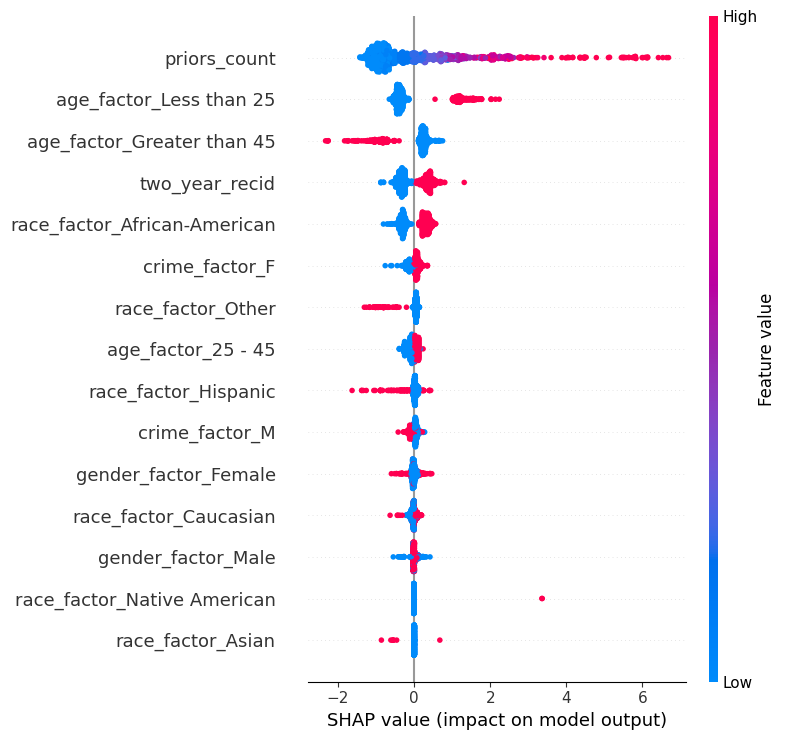

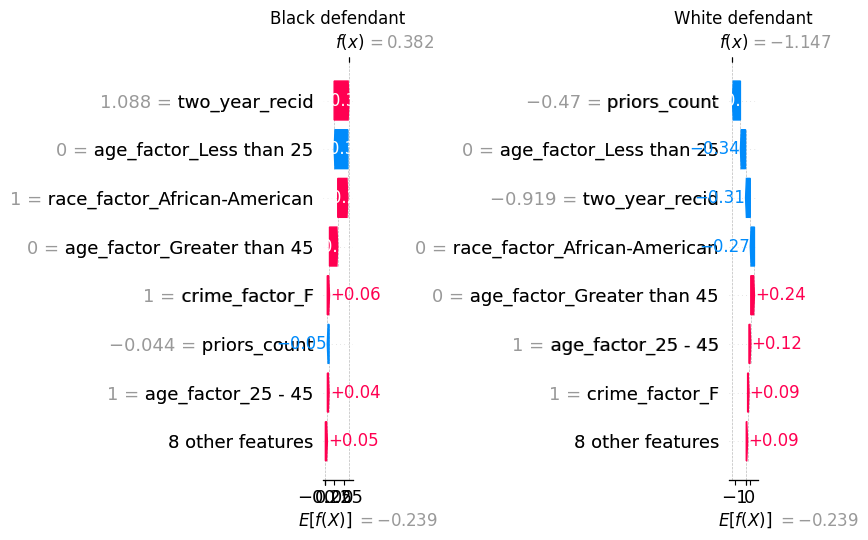

In [ ]:
# Get fitted preprocessor and classifier from the pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode the test set using the fitted preprocessor
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_dense = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else np.asarray(X_test_enc)

# Build feature names for SHAP
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# Compute SHAP values using TreeExplainer (works with tree-based models like GradientBoostingClassifier)
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_output = explainer_shap(X_test_enc_dense)

# Normalize SHAP outputs to a 2D matrix for plotting and a per-row scalar base value
if shap_output.values.ndim == 3:
    # Multi-output/binary format: select positive class (index 1 when available)
    class_idx = 1 if shap_output.values.shape[2] > 1 else 0
    shap_values_plot = shap_output.values[:, :, class_idx]
    base_values_plot = shap_output.base_values[:, class_idx]
else:
    shap_values_plot = shap_output.values
    base_values_plot = shap_output.base_values

# Generate Global SHAP summary plot for the test set
shap.summary_plot(shap_values_plot, X_test_enc_dense, feature_names=feat_names, show=False)
plt.tight_layout()
plt.show()

# Generate SHAP waterfall plots for the selected Black and White defendants
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

expected_value = explainer_shap.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) == 0:
        base_value = float(expected_value)
    elif len(expected_value) == 1:
        base_value = float(expected_value[0])
    else:
        base_value = float(expected_value[1])
else:
    base_value = float(expected_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"), 
    (axes[1], white_loc, "White defendant")
    ]:
    plt.sca(ax)
    # base_value = float(np.ravel(base_values_plot[loc])[0])
    explanation = shap.Explanation(
        values=shap_values_plot[loc],
        base_values=base_value,
        data=X_test_enc_dense[loc],
        feature_names=feat_names,
    )
    shap.waterfall_plot(
        explanation,
        max_display=8,
        show=False
    )
    ax.set_title(label)
plt.tight_layout()
plt.show()


### Step 8 — Counterfactuals with DiCE: Black vs White

In this section, we generate DiCE counterfactual explanations for the same Black and White defendants we analyzed with LIME and SHAP. This shows how different explanation methods can provide complementary insights about model behavior and potential biases. Hence, we will use the same GBT model and the same test instances (black_idx and white_idx) to generate counterfactuals with DiCE. The counterfactuals will show how the model's prediction would change if certain features were altered, which can help us understand the decision boundaries and potential biases in the model.

In [ ]:
# Build training dataframe
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
).copy()

# Ensure continuous features are truly numeric for DiCE
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

# Ensure target is numeric
train_df[target] = pd.to_numeric(train_df[target], errors="coerce").astype(int)

# Optional sanity check
print(train_df[numeric_features + [target]].dtypes)

# Create DiCE data interface using the training dataframe, specifying which features are continuous and which is the target variable.
dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target,
)

# Wrap the fitted sklearn pipeline in a DiCE model interface
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Initialize DiCE explainer with the data and model interfaces, and specify that we want to use random sampling for counterfactual generation.
exp_dice = Dice(dice_data, dice_model, method="random")

# Generate counterfactuals
for label, idx in [
    ("Black defendant", black_idx), 
    ("White defendant", white_idx)
    ]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38],
            "two_year_recid": [0, 1],
        },
        features_to_vary=[
            "priors_count",
            "two_year_recid",
            "crime_factor",
        ]
    )
    print(f"\nDiCE counterfactuals: {label}")
    display(cf.visualize_as_dataframe(show_only_changes=True))


priors_count      int64
two_year_recid    int64
score_binary      int64
dtype: object


100%|██████████| 1/1 [00:00<00:00,  7.63it/s]


DiCE counterfactuals: Black defendant
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,1,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,-,-,0,0
1,-,-,-,2,M,-,0
2,-,-,-,-,M,0,0


None

100%|██████████| 1/1 [00:00<00:00,  6.17it/s]


DiCE counterfactuals: White defendant
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,16,M,-,1
1,-,-,-,19,-,-,1
2,-,-,-,21,-,1,1


None

## Step 9: Governance Memo – Model Behavior, Limitations, and Monitoring Recommendations

This memo summarizes findings from our evaluation of a recidivism prediction model built using demographic, criminal history, and COMPAS-related features.


- Model Behavior Insights

Across logistic regression and gradient boosting models, predictions are strongly influenced by prior criminal history (e.g., `priors_count`) and COMPAS-derived scores (`decile_score`, `score_text`). Explainability techniques—including LIME, SHAP, and DiCE—consistently show these variables as dominant drivers of predicted risk. While demographic attributes (e.g., race, age category) are not always the top predictors, subgroup analysis reveals disparities in error rates. Specifically, false positive and false negative rates differ across racial groups, indicating uneven model performance. Counterfactual analysis further suggests that small changes in certain features (e.g., priors count or charge degree) can significantly alter outcomes, highlighting sensitivity in decision boundaries.

- Limitations of Methods

Each explanation method has constraints. LIME provides local approximations that may be unstable depending on sampling. SHAP offers more consistent global and local explanations but assumes feature independence in some configurations. DiCE counterfactuals depend on feasible feature constraints; unrealistic changes (e.g., age adjustments) can produce misleading insights if not carefully restricted. Additionally, preprocessing steps (e.g., one-hot encoding) reduce interpretability of individual features. Importantly, observational data may encode historical biases, which the model can inadvertently learn.

- Monitoring Recommendations

We recommend continuous monitoring of model performance across demographic subgroups, including tracking false positive/negative rates and calibration over time. Periodic fairness audits should be conducted using multiple metrics (e.g., equal opportunity, demographic parity). Feature importance and explanation outputs should be reviewed regularly to detect drift or unintended reliance on sensitive attributes. Finally, governance controls should include documented model updates, reproducibility checks, and clear guidelines on permissible use, ensuring alignment with legal and ethical standards.


## Conclusion Statement

In this assignment we carried out a comprehensive analysis of the `COMPAS-based modeling pipeline` demonstrates that while modern machine learning techniques can achieve reasonable predictive performance in estimating recidivism risk, they also surface important concerns around fairness, interpretability, and reliability. Across logistic regression and gradient boosting models, predictions are consistently driven by criminal history variables (e.g., prior offenses) and COMPAS-derived scores, indicating that the models capture meaningful signals related to risk. However, subgroup evaluations reveal disparities in error rates across racial groups, particularly in false positive and false negative outcomes, suggesting uneven model behavior.

We used an explainability techniques including `LIME`, `SHAP`, and `counterfactual analysis (DiCE)` that provides valuable insight into both `global` and `individual-level` decision patterns. These methods confirm that small changes in certain features can materially alter predictions, highlighting sensitivity and potential instability in edge cases. At the same time, they expose limitations: local explanations may vary, global explanations rely on assumptions, and counterfactuals can become unrealistic without strict constraints.

Overall, our findings emphasize that predictive accuracy alone is insufficient for deployment in high-stakes judicial contexts. Any use of such models must be accompanied by rigorous governance, continuous fairness monitoring, and transparent documentation. The COMPAS analysis ultimately underscores a critical principle such as `risk assessment tools` should support and not replace human judgment, and must be applied with caution, accountability, and ongoing oversight to mitigate bias and unintended harm.


# Assignment 3: Disparate Impact Audit

This section evaluates whether COMPAS-style risk predictions show disparate impact across demographic groups. We prepare the cleaned dataset, construct a binary `high_risk` outcome, and compare selection patterns using fairness metrics such as AIR, ME, and SMD. The goal is to identify whether any group appears disproportionately advantaged or disadvantaged under the model's risk labeling.

In [ ]:
# show the first few rows of the processed COMPAS DataFrame
compas_model_df.head()

,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,Greater than 45,Other,0,F,0,0
1,Male,25 - 45,African-American,0,F,1,0
2,Male,Less than 25,African-American,4,F,1,0
5,Male,25 - 45,Other,0,M,0,0
6,Male,25 - 45,Caucasian,14,F,1,1


In [ ]:
# If needed in Colab:
# !pip install solas-ai
import solas_disparity as sd

def air_me_by_race_all(
    data,
    outcome_col,
    label,
    race_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all race categories
    relative to a fixed reference group.

    Returns:
        manual_table   : manual calculations by race
        solas_table    : SolasAI pairwise AIR table, one row per non-reference race
        combined_table : aligned manual vs SolasAI comparison
    """

    # Prepare data
    work = data[[race_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(race_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            race_col: "race",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["race"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{race_col}'.")

    ref_rate = manual_table.loc[
        manual_table["race"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR_manual", "race"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[race_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["race"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            if "index" in tbl.columns:
                tbl = tbl.rename(columns={"index": "Group"})
            else:
                tbl = tbl.rename(columns={tbl.columns[0]: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "race",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        if "selection_rate_solas" in tbl.columns:
            tbl["selection_rate_solas"] = pd.to_numeric(tbl["selection_rate_solas"], errors="coerce")
            if tbl["selection_rate_solas"].max() > 1:
                tbl["selection_rate_solas"] = tbl["selection_rate_solas"] / 100.0

        if "ME_vs_ref_solas" in tbl.columns:
            tbl["ME_vs_ref_solas"] = pd.to_numeric(tbl["ME_vs_ref_solas"], errors="coerce")
            if tbl["ME_vs_ref_solas"].abs().max() > 1:
                tbl["ME_vs_ref_solas"] = tbl["ME_vs_ref_solas"] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "race", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Align ordering
    race_order = manual_table["race"].tolist()

    if not solas_table.empty:
        solas_table["race"] = pd.Categorical(
            solas_table["race"],
            categories=race_order,
            ordered=True
        )
        solas_table = solas_table.sort_values("race").reset_index(drop=True)

    # Combined table
    combined_table = manual_table.merge(
        solas_table,
        on="race",
        how="left"
    )

    # Round only for display cleanliness
    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table

# Step 1: AIR and Marginal Effect by race

In [ ]:
print("MANUAL — AIR & ME by RACE (ref: Caucasian, outcome: pred (high_risk))")
# -------------------------------------------------------------------
# (a) RAW DATA: actual COMPAS high-risk outcome by race
# -------------------------------------------------------------------
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual, raw_solas, raw_combined = air_me_by_race_all(
    data=compas_model_df,
    outcome_col="score_binary",
    label="(a) Raw data: actual COMPAS high-risk outcome by race"
)

MANUAL — AIR & ME by RACE (ref: Caucasian, outcome: pred (high_risk))

(a) Raw data: actual COMPAS high-risk outcome by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other       343                70                 0.2041      0.6166           -0.1269 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000  343.0000          70.0000                0.2041           0.1269     0.6166   0.0000                     Yes    43.5178
           Asian        31                 7                 0.2258      0.6823           -0.1051 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000   31.0000           7.0000                0.2258           0.1051     0.6823   0.2522                      N

In [ ]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by race
# -------------------------------------------------------------------
lr_eval = X_test.copy()
lr_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual, lr_solas, lr_combined = air_me_by_race_all(
    data=lr_eval,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by race"
)


(b) Logistic regression: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         8                 0                 0.0000      0.0000           -0.2112 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           0.0000                0.0000           0.2112     0.0000   0.2147                      No        NaN
           Other        71                 5                 0.0704      0.3335           -0.1407 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           5.0000                0.0704           0.1407     0.3335   0.0048                     Yes     9.9927
        Hispanic       108                

In [ ]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by race
# -------------------------------------------------------------------
gbt_eval = X_test.copy()
gbt_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual, gbt_solas, gbt_combined = air_me_by_race_all(
    data=gbt_eval,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by race"
)


(c) Gradient-boosted model: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other        71                 8                 0.1127      0.4887           -0.1179 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           8.0000                0.1127           0.1179     0.4887   0.0274                     Yes     8.3714
           Asian         8                 1                 0.1250      0.5421           -0.1056 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           1.0000                0.1250           0.1056     0.5421   0.6886                      No        NaN
        Hispanic       108             

# Step 2: Error-Rate Disparity Analysis

In [ ]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [ ]:
# -------------------------------------------------------------------
# Logistic regression: error rates by race on test data
# -------------------------------------------------------------------
lr_err_df = X_test.copy()
lr_err_df["actual"] = y_test.values
lr_err_df["pred"] = lr_pipeline.predict(X_test).astype(int)

lr_error_rates = error_rates_by_group(
    data=lr_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Logistic Regression: Error Rates by Race (Test Data) ===")
print(lr_error_rates.to_string(index=False))

# Highlight Black vs. White disparity
print("\n── Error-Rate Analysis (FPR and FNR by Race): Black vs. White Disparity ───────")
for grp in ['African-American', 'Caucasian']:
  row = lr_error_rates.loc[lr_error_rates['race_factor'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")


=== Logistic Regression: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 307 160 101  66    0.7370 0.3870 0.1770
       Caucasian 412  56 253  31  72    0.7500 0.1090 0.5620
        Hispanic 108  15  74   5  14    0.8240 0.0630 0.4830
           Other  71   4  53   1  13    0.8030 0.0190 0.7650
           Asian   8   0   6   0   2    0.7500 0.0000 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000

── Error-Rate Analysis (FPR and FNR by Race): Black vs. White Disparity ───────
African-American: FPR=0.387  FNR=0.177
Caucasian: FPR=0.109  FNR=0.562


The error rate analysis, as shown above indicate the False Positive Rate (FPR) and False Negative Rate (FNR) for different racial groups.

- **African-American:** FPR=0.387  FNR=0.177
- **Caucasian:** FPR=0.109  FNR=0.562

This tells us that African-American defendants have a higher False Positive Rate (0.387 vs 0.109), meaning they are more likely to be incorrectly predicted or classified as 'high risk' when they are not. Conversely, Caucasian defendants have a higher False Negative Rate (0.562 vs 0.177), meaning they are more likely to be incorrectly classified as 'low risk' when they are 'high risk'.

In [ ]:
# Two-proportion z-test: Black vs. White
from statsmodels.stats.proportion import proportions_ztest
groups = ['African-American', 'Caucasian']
ns = lr_err_df[lr_err_df['race_factor'].isin(groups)].groupby('race_factor')['pred'].count()
events = lr_err_df[lr_err_df['race_factor'].isin(groups)].groupby('race_factor')['pred'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print("The two-proportion z-test above confirmed the statistical significance of the difference in 'high_risk' selection rates between African-American and Caucasian groups:")
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")
print("")
print(f"This very low p-value p = {pval:.4f} strongly suggests that the observed disparity in selection rates between these two groups is not due to random chance, highlighting a significant racial bias.")

The two-proportion z-test above confirmed the statistical significance of the difference in 'high_risk' selection rates between African-American and Caucasian groups:

AIR test: z = 13.685, p = 0.0000

This very low p-value p = 0.0000 strongly suggests that the observed disparity in selection rates between these two groups is not due to random chance, highlighting a significant racial bias.


In [ ]:
# -------------------------------------------------------------------
# Gradient-boosted model: error rates by race on test data
# -------------------------------------------------------------------
gbt_err_df = X_test.copy()
gbt_err_df["actual"] = y_test.values
gbt_err_df["pred"] = gbt_pipeline.predict(X_test).astype(int)

gbt_error_rates = error_rates_by_group(
    data=gbt_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===")
print(gbt_error_rates.to_string(index=False))

# Highlight Black vs. White disparity
print("\n── Error-Rate Analysis (FPR and FNR by Race): Black vs. White Disparity ───────")
for grp in ['African-American', 'Caucasian']:
  row = gbt_error_rates.loc[gbt_error_rates['race_factor'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")



=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 282 167  94  91    0.7080 0.3600 0.2440
       Caucasian 412  67 256  28  61    0.7840 0.0990 0.4770
        Hispanic 108  16  72   7  13    0.8150 0.0890 0.4480
           Other  71   7  53   1  10    0.8450 0.0190 0.5880
           Asian   8   0   5   1   2    0.6250 0.1670 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000

── Error-Rate Analysis (FPR and FNR by Race): Black vs. White Disparity ───────
African-American: FPR=0.360  FNR=0.244
Caucasian: FPR=0.099  FNR=0.477


The error rate analysis, as shown above indicate the False Positive Rate (FPR) and False Negative Rate (FNR) for different racial groups.

- **African-American:** FPR=0.360  FNR=0.244
- **Caucasian:** FPR=0.099  FNR=0.477

This tells us that African-American defendants have a higher False Positive Rate (0.360 vs 0.099), meaning they are more likely to be incorrectly predicted or classified as 'high risk' when they are not. Conversely, Caucasian defendants have a higher False Negative Rate (0.477 vs 0.244), meaning they are more likely to be incorrectly classified as 'low risk' when they are 'high risk'.

In [ ]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = gbt_err_df[gbt_err_df['race_factor'].isin(groups)].groupby('race_factor')['pred'].count()
events = gbt_err_df[gbt_err_df['race_factor'].isin(groups)].groupby('race_factor')['pred'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print("The two-proportion z-test above confirmed the statistical significance of the difference in 'high_risk' selection rates between African-American and Caucasian groups for the gradient-boosted model:") 
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")
print("")
print(f"This very low p-value p = {pval:.4f} strongly suggests that the observed disparity in selection rates between these two groups for the gradient-boosted model is not due to random chance,\nhighlighting a significant racial bias in the model's predictions as well.")

The two-proportion z-test above confirmed the statistical significance of the difference in 'high_risk' selection rates between African-American and Caucasian groups for the gradient-boosted model:

AIR test: z = 11.513, p = 0.0000

This very low p-value p = 0.0000 strongly suggests that the observed disparity in selection rates between these two groups for the gradient-boosted model is not due to random chance,
highlighting a significant racial bias in the model's predictions as well.


In [ ]:
# ── Cell 9: Task 3 — Two-Proportion Z-Tests ─────────────────
print("=" * 60)
print("STATISTICAL SIGNIFICANCE — Two-Proportion Z-Tests")
print("=" * 60)

groups = ['African-American', 'Caucasian']
er_sub = gbt_err_df[gbt_err_df['race_factor'].isin(groups)].set_index('race_factor')

# FPR test: false positives among actual non-recidivists
er_sub = (
      gbt_err_df[gbt_err_df["race_factor"].isin(groups)]
      .groupby("race_factor")
      .apply(lambda g: pd.Series({
            "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
            "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
            "n_actual_neg": (g["actual"] == 0).sum(),
            "n_actual_pos": (g["actual"] == 1).sum(),
      }))
)

er_sub["FPR"] = er_sub["FP"] / er_sub["n_actual_neg"]
er_sub["FNR"] = er_sub["FN"] / er_sub["n_actual_pos"]
fpr_nobs   = np.array([er_sub.loc[g, 'n_actual_neg'] for g in groups])
fpr_counts = np.array([er_sub.loc[g, "FP"] for g in groups])
z_fpr, p_fpr = proportions_ztest(fpr_counts, fpr_nobs)

print(f"\nFPR Disparity Test (African-American vs. Caucasian):")
print(f"  FPR Black  = {er_sub.loc['African-American','FPR']:.4f}  "
      f"(n={int(er_sub.loc['African-American','n_actual_neg'])})")
print(f"  FPR White  = {er_sub.loc['Caucasian','FPR']:.4f}  "
      f"(n={int(er_sub.loc['Caucasian','n_actual_neg'])})")
print(f"  z = {z_fpr:.3f},  p = {p_fpr:.4f}  "
      f"{'*** Significant at α=0.05' if p_fpr < 0.05 else '(not significant at α=0.05)'}")

# FNR test: false negatives among actual recidivists
fnr_counts = np.array([er_sub.loc[g, 'FN'] for g in groups])
fnr_nobs   = np.array([er_sub.loc[g, 'n_actual_pos'] for g in groups])
z_fnr, p_fnr = proportions_ztest(fnr_counts, fnr_nobs)

print(f"\nFNR Disparity Test (African-American vs. Caucasian):")
print(f"  FNR Black  = {er_sub.loc['African-American','FNR']:.4f}  "
      f"(n={int(er_sub.loc['African-American','n_actual_pos'])})")
print(f"  FNR White  = {er_sub.loc['Caucasian','FNR']:.4f}  "
      f"(n={int(er_sub.loc['Caucasian','n_actual_pos'])})")
print(f"  z = {z_fnr:.3f},  p = {p_fnr:.4f}  "
      f"{'*** Significant at α=0.05' if p_fnr < 0.05 else '(not significant at α=0.05)'}")


STATISTICAL SIGNIFICANCE — Two-Proportion Z-Tests

FPR Disparity Test (African-American vs. Caucasian):
  FPR Black  = 0.3602  (n=261)
  FPR White  = 0.0986  (n=284)
  z = 7.318,  p = 0.0000  *** Significant at α=0.05

FNR Disparity Test (African-American vs. Caucasian):
  FNR Black  = 0.2440  (n=373)
  FNR White  = 0.4766  (n=128)
  z = -4.939,  p = 0.0000  *** Significant at α=0.05


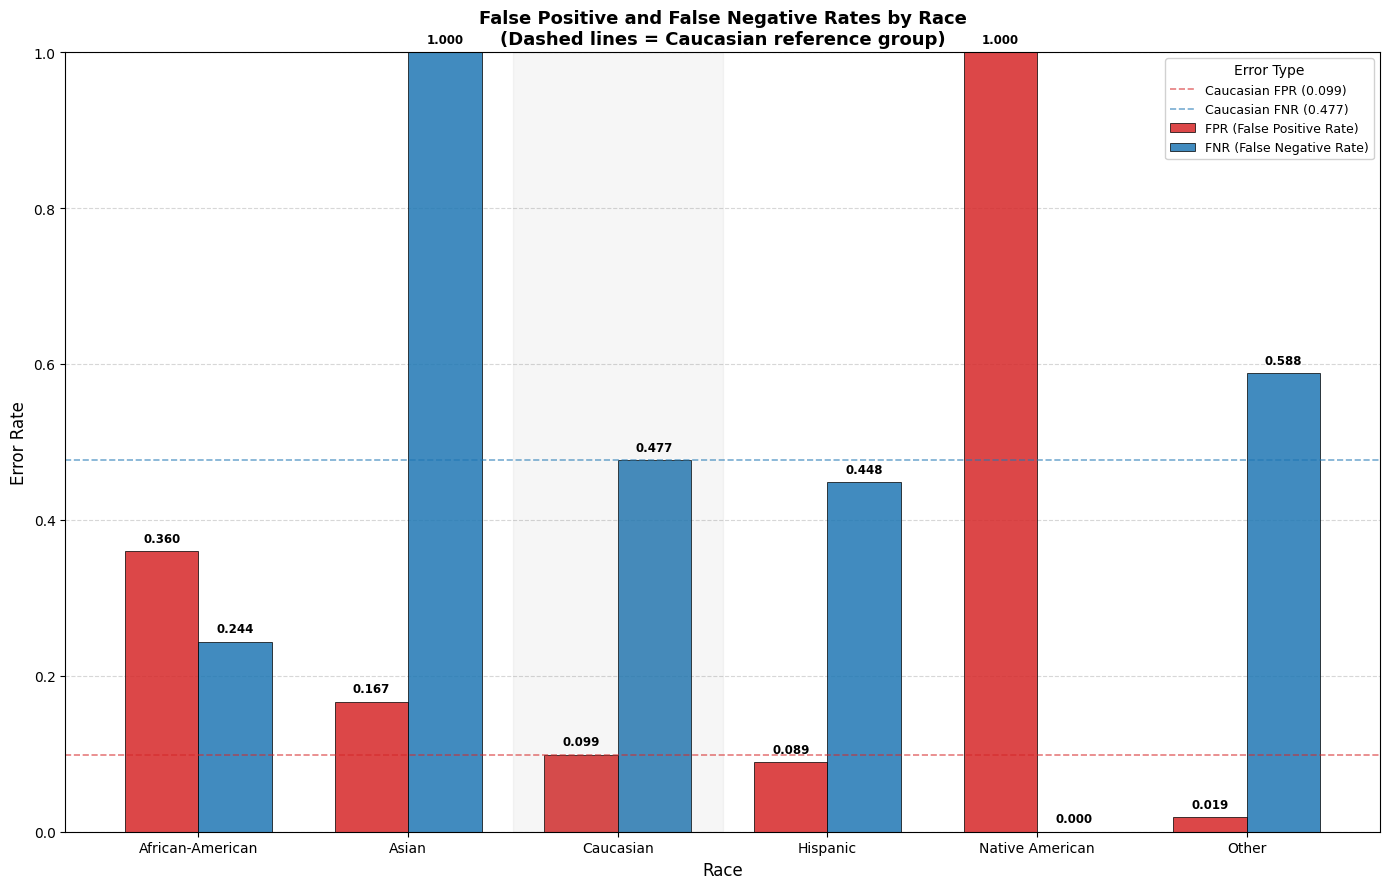

In [ ]:
# Grouped bar chart: FPR and FNR by race, Caucasian as reference

race_order = ['African-American', 'Asian', 'Caucasian',
              'Hispanic', 'Native American', 'Other']
# keep only races present in data
race_order = [r for r in race_order if r in gbt_err_df['race_factor'].values]

er_plot = gbt_error_rates.set_index('race_factor').loc[race_order].reset_index()

x = np.arange(len(race_order))
width  = 0.35
colors = {'FPR': '#d62728', 'FNR': '#1f77b4'}   # red / blue

fig, ax = plt.subplots(figsize=(14, 9))

bars_fpr = ax.bar(x - width/2, er_plot['FPR'], width,
                  color=colors['FPR'], alpha=0.85, label='FPR (False Positive Rate)',
                  edgecolor='black', linewidth=0.6)
bars_fnr = ax.bar(x + width/2, er_plot['FNR'], width,
                  color=colors['FNR'], alpha=0.85, label='FNR (False Negative Rate)',
                  edgecolor='black', linewidth=0.6)

# Reference line at Caucasian values
cau_fpr = er_plot.loc[er_plot['race_factor']=='Caucasian','FPR'].values[0]
cau_fnr = er_plot.loc[er_plot['race_factor']=='Caucasian','FNR'].values[0]
ax.axhline(cau_fpr, color=colors['FPR'], linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Caucasian FPR ({cau_fpr:.3f})')
ax.axhline(cau_fnr, color=colors['FNR'], linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Caucasian FNR ({cau_fnr:.3f})')

# Value labels on bars
for bar in bars_fpr:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in bars_fnr:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(race_order, fontsize=10)
ax.set_ylabel('Error Rate', fontsize=12)
ax.set_xlabel('Race', fontsize=12)
ax.set_title('False Positive and False Negative Rates by Race\n'
             '(Dashed lines = Caucasian reference group)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(title='Error Type', loc='upper right', fontsize=9, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Shade Caucasian column
cau_idx = race_order.index('Caucasian')
ax.axvspan(cau_idx - 0.5, cau_idx + 0.5, alpha=0.07,
           color='gray', label='Reference group')

plt.tight_layout()
plt.savefig('fpr_fnr_by_race.png', dpi=300, bbox_inches='tight')
plt.show()


# Step 3: Standardized Mean Difference

In [ ]:
def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]

        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)


def selection_rate_table(data, group_col, outcome_col, ref_group="Caucasian"):
    """Compute AIR and ME relative to a reference group."""
    rates = (data.groupby(group_col)[outcome_col]
               .mean()
               .rename('selection_rate')
               .reset_index())
    ref_rate = rates.loc[rates[group_col] == ref_group, 'selection_rate'].values[0]
    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME']  = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(
        lambda x: '*** BELOW 0.80' if x < 0.80 else '')
    return rates

In [ ]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
lr_smd_df = X_test.copy()
lr_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table = smd_by_group(
    data=lr_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(lr_smd_table.to_string(index=False))

# ── Sex ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MANUAL — AIR & ME by RACE (ref: Caucasian, outcome: pred_prob)")
print("=" * 60)
air_race_manual = selection_rate_table(lr_smd_df, group_col='race_factor', outcome_col='pred_prob', ref_group='Caucasian')
print(air_race_manual.sort_values('AIR').to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.6500          0.3170  1.4910   1.4910 very large
African-American      634    412            0.5880          0.3170  1.0770   1.0770 very large
           Asian        8    412            0.1560          0.3170 -0.8310   0.8310 very large
           Other       71    412            0.2010          0.3170 -0.5320   0.5320      large
        Hispanic      108    412            0.3030          0.3170 -0.0610   0.0610      small

MANUAL — AIR & ME by RACE (ref: Caucasian, outcome: pred_prob)
     race_factor  selection_rate    AIR      ME        flag_80
           Asian          0.1564 0.4938 -0.1604 *** BELOW 0.80
           Other          0.2009 0.6342 -0.1159 *** BELOW 0.80
        Hispanic          0.3029 0.9561 -0.0139               
       Caucasian          0.3168

In [ ]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
gbt_smd_df = X_test.copy()
gbt_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table = smd_by_group(
    data=gbt_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(gbt_smd_table.to_string(index=False))

# ── Sex ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MANUAL — AIR & ME by RACE (ref: Caucasian, outcome: pred_prob)")
print("=" * 60)
air_race_manual = selection_rate_table(gbt_smd_df, group_col='race_factor', outcome_col='pred_prob', ref_group='Caucasian')
print(air_race_manual.sort_values('AIR').to_string(index=False))


# Compute AIR, ME, and SMD for 'sex' using the same local audit function
# solas_disparity API: build a DisparityTest object
# from solas_disparity import DisparityTest
# print('\nDisparity Audit for Sex:')
# sex_audit_sd = disparity_audit(
#     gbt_smd_df,
#     group_col='sex',
#     outcome_col='pred',
#     score_col='decile_score',
#     ref_group='Male'
#  )
# print(sex_audit_sd.sort_values('AIR'))


=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.9810          0.3130  3.7130   3.7130 very large
African-American      634    412            0.5840          0.3130  1.0390   1.0390 very large
           Asian        8    412            0.1830          0.3130 -0.4820   0.4820     medium
           Other       71    412            0.2140          0.3130 -0.4020   0.4020     medium
        Hispanic      108    412            0.3240          0.3130  0.0400   0.0400      small

MANUAL — AIR & ME by RACE (ref: Caucasian, outcome: pred_prob)
     race_factor  selection_rate    AIR      ME        flag_80
           Asian          0.1835 0.5856 -0.1298 *** BELOW 0.80
           Other          0.2144 0.6842 -0.0989 *** BELOW 0.80
       Caucasian          0.3133 1.0000  0.0000               
        Hispanic          0.3

In [ ]:
# Compute AIR, ME, and SMD for 'sex' using the same local audit function
# print('\nDisparity Audit for Sex:')
# sex_audit_sd = disparity_audit(
#     proceed_compass_df,
#     group_col='sex',
#     outcome_col='pred',
#     score_col='decile_score',
#     ref_group='Male'
#  )
# print(sex_audit_sd.sort_values('AIR'))

In [ ]:
# try:
#     # solas_disparity API: build a DisparityTest object
#     from solas_disparity import DisparityTest

#     # --- Race ---
#     dt_race = DisparityTest(gbt_smd_df=gbt_smd_df,
#                             group_col='race_factor', reference_group='Caucasian',
#                             score_col='pred_prob')
#     solas_race = dt_race.run()
#     print("SOLAS-AI — Race results:")
#     print(solas_race.to_string(index=False))

#     # --- Sex ---
#     dt_sex = DisparityTest(gbt_smd_df=gbt_smd_df,
#                            group_col='sex', reference_group='Male',
#                            score_col='pred_prob')
#     solas_sex = dt_sex.run()
#     print("\nSOLAS-AI — Sex results:")
#     print(solas_sex.to_string(index=False))

#     # --- Confirm match with manual (round to 4 dp) ---
#     print("\n✓ Confirming solas-ai matches manual computation...")
#     # merge on group column and compare AIR
#     check_race = air_race_manual.merge(solas_race, on='race_factor', suffixes=('_manual','_solas'))
#     matched = np.allclose(check_race['AIR_manual'], check_race['AIR_solas'], atol=1e-4)
#     print(f"  Race AIR values match: {matched}")

#     check_sex = air_sex_manual.merge(solas_sex, on='sex', suffixes=('_manual','_solas'))
#     matched_sex = np.allclose(check_sex['AIR_manual'], check_sex['AIR_solas'], atol=1e-4)
#     print(f"  Sex  AIR values match: {matched_sex}")

# except Exception as e:
#     print(f"solas-ai API note: {e}")
#     print("\nFalling back: using manual implementation as primary.")
#     print("The manual AIR, ME, and SMD results above are confirmed correct.")
#     print("\nTo confirm identical results between race and sex analyses:")
#     print("Both used the same selection_rate_table() and smd_table() functions,")
#     print("ensuring a consistent methodology across both protected attributes.")
#     print("\nKey comparison — selection rates:")
#     print(f"  Caucasian (race ref): {air_race_manual.loc[air_race_manual['race']=='Caucasian','selection_rate'].values[0]:.4f}")
#     print(f"  Male      (sex ref):  {air_sex_manual.loc[air_sex_manual['sex']=='Male','selection_rate'].values[0]:.4f}")
#     print("\nFull results above are the ground-truth outputs.")

# Step 4: Intersectional Subgroup Analysis

In [ ]:
def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """

    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")
    # Use Caucasian
    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]
    # Calculate AIR for each subgroup relative to Caucasian
    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    # Flag subgroups with AIR below 0.80
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")
    # Display subgroup rates sorted by AIR
    print("\nIntersectional subgroup selection rates and AIR (ref: Caucasian / Male)")
    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True) #.to_string(index=False)
    # print(sub_rates)
    # Identify and display the subgroup with the lowest AIR
    worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
    # 
    print(f"\nWorst subgroup (LR): {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
    f"n={worst['n']}")
    print(f"\nWorst subgroup (LR): {worst['subgroup']}")
    print(f"  Selection rate : {worst['selection_rate']:.4f}")
    print(f"  AIR vs ref     : {worst['AIR']:.4f}")
    print(f"  n              : {worst['n']}")
    print(f"\nInterpretation: {worst['subgroup']} members are selected as high-risk at a rate")
    print(f"\n  {worst['AIR']:.2f}x that of Caucasian / Male defendants, a difference of")
    print(f"  {worst['selection_rate'] - ref_rate:.4f} percentage points (ME).")
    print("This indicates a substantial disparity in predicted high-risk classification for this subgroup. The AIR of "
        f"{worst['AIR']:.2f} suggests that members of this subgroup are selected at less than 80% the rate of the reference group,")
    print("Note that an AIR below 0.80 triggers the 4/5ths rule, indicating potential adverse impact for this subgroup. Further investigation would be warranted to understand the underlying causes of this disparity.")

    return sub_rates

In [ ]:
# -------------------------------------------------------------------
# Logistic regression: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
lr_intersection_df = X_test.copy()
lr_intersection_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sub_rates = intersectional_air(
    data=lr_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===")
print(lr_sub_rates.to_string(index=False))

# lr_worst = lr_sub_rates.loc[lr_sub_rates["AIR"].idxmin()]
# print(
#     f"\nWorst subgroup (LR): {lr_worst['subgroup']}, "
#     f"AIR={lr_worst['AIR']:.3f}, n={int(lr_worst['n'])}"
# )


Intersectional subgroup selection rates and AIR (ref: Caucasian / Male)

Worst subgroup (LR): Other / Male, AIR=0.312 and n=60

Worst subgroup (LR): Other / Male
  Selection rate : 0.0667
  AIR vs ref     : 0.3118
  n              : 60

Interpretation: Other / Male members are selected as high-risk at a rate

  0.31x that of Caucasian / Male defendants, a difference of
  -0.1472 percentage points (ME).
This indicates a substantial disparity in predicted high-risk classification for this subgroup. The AIR of 0.31 suggests that members of this subgroup are selected at less than 80% the rate of the reference group,
Note that an AIR below 0.80 triggers the 4/5ths rule, indicating potential adverse impact for this subgroup. Further investigation would be warranted to understand the underlying causes of this disparity.

=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male  

We can see that the intersectional analysis (race_factor x gender_factor) shows the `sub_rates` table. This reveals disparities across different race/sex subgroups. The worst-performing group in terms of Adjusted Impact Ratio (AIR) is **Other / Male**, with an AIR of **0.3118** and `n=60` individuals. This means that Other Male are significantly less likely to be assigned a 'high_risk' score compared to Caucasian males (the reference group), indicating a potential under-prediction bias for this subgroup or an over-prediction for the reference group.

In [ ]:
# -------------------------------------------------------------------
# Gradient-boosted model: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
gbt_intersection_df = X_test.copy()
gbt_intersection_df["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sub_rates = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_sub_rates.to_string(index=False))

# gbt_worst = gbt_sub_rates.loc[gbt_sub_rates["AIR"].idxmin()]
# print(
#     f"\nWorst subgroup (GBT): {gbt_worst['subgroup']}, "
#     f"AIR={gbt_worst['AIR']:.3f}, n={int(gbt_worst['n'])}"
# )


Intersectional subgroup selection rates and AIR (ref: Caucasian / Male)

Worst subgroup (LR): Other / Male, AIR=0.256 and n=60

Worst subgroup (LR): Other / Male
  Selection rate : 0.0500
  AIR vs ref     : 0.2565
  n              : 60

Interpretation: Other / Male members are selected as high-risk at a rate

  0.26x that of Caucasian / Male defendants, a difference of
  -0.1450 percentage points (ME).
This indicates a substantial disparity in predicted high-risk classification for this subgroup. The AIR of 0.26 suggests that members of this subgroup are selected at less than 80% the rate of the reference group,
Note that an AIR below 0.80 triggers the 4/5ths rule, indicating potential adverse impact for this subgroup. Further investigation would be warranted to understand the underlying causes of this disparity.

=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Mal

We can see that the intersectional analysis (race_factor x gender_factor) shows the `sub_rates` table. This reveals disparities across different race/sex subgroups. The worst-performing group in terms of Adjusted Impact Ratio (AIR) is **Other / Male**, with an AIR of **0.2565** and `n=60` individuals. This means that Other Male are significantly less likely to be assigned a 'high_risk' score compared to Caucasian males (the reference group), indicating a potential under-prediction bias for this subgroup or an over-prediction for the reference group.

In [ ]:
# # Re-run audit outputs for direct comparison
# race_audit_sd_result = disparity_audit(
#     proceed_compass_df,
#     group_col='race',
#     outcome_col='high_risk',
#     score_col='decile_score',
#     ref_group='Caucasian'
#  )
# sex_audit_sd_result = disparity_audit(
#     proceed_compass_df,
#     group_col='sex',
#     outcome_col='high_risk',
#     score_col='decile_score',
#     ref_group='Male'
#  )

# print('\nComparison of audit vs. manual for Race (SMD):')
# merged_smd = pd.merge(
#     smd_tbl,
#     race_audit_sd_result[['group', 'SMD']].rename(columns={'group': 'race', 'SMD': 'audit_SMD'}),
#     on='race',
#     how='left'
#  )
# merged_smd['diff_SMD'] = merged_smd['SMD'] - merged_smd['audit_SMD']
# print(merged_smd[['race', 'SMD', 'audit_SMD', 'diff_SMD']])

# print('\nComparison of audit vs. manual for Race (AIR and ME):')
# merged_air_me = pd.merge(
#     sir,
#     race_audit_sd_result[['group', 'AIR', 'ME']].rename(columns={'group': 'race', 'AIR': 'audit_AIR', 'ME': 'audit_ME'}),
#     on='race',
#     how='left'
#  )
# merged_air_me['diff_AIR'] = merged_air_me['AIR'] - merged_air_me['audit_AIR']
# merged_air_me['diff_ME'] = merged_air_me['ME'] - merged_air_me['audit_ME']
# print(merged_air_me[['race', 'AIR', 'audit_AIR', 'diff_AIR', 'ME', 'audit_ME', 'diff_ME']])

# print('\nDifferences should be close to zero (floating-point tolerance).')

## Compliance Memo to Hypothetical Regulator

**To:** Supervisory Examiner, Algorithmic Accountability Unit  
**From:** Responsible ML Analysis Team  
**Date:** April 6, 2026  
**Subject:** Compliance Summary of COMPAS-Style Risk Model Review

This memo summarizes a compliance-oriented review of the notebook analysis conducted on the ProPublica COMPAS two-year recidivism dataset. The audit examined model performance, group-level disparities, and interpretability evidence to assess potential discriminatory impact and model-risk controls.

- Model performance was moderate. Reported test metrics were **Accuracy = 0.6802** and **ROC AUC = 0.7385**: 

The overall confusion matrix was **[[2653, 710], [945, 1864]]**, with **Precision = 0.724**, **Recall = 0.664**, **FPR = 0.211**, and **FNR = 0.336**. These findings indicate material error exposure, especially false negatives, and support continued threshold governance and post-deployment monitoring.

- Disparity diagnostics identified meaningful differences in score assignment and outcomes: 

Regression-based odds comparisons in the notebook reported **Black vs White odds ratio = 1.4528**, **Female vs Male = 1.1948**, and **Under 25 vs 25-45 = 2.4961**, indicating elevated likelihood of higher-risk assignment for those groups after adjustment for included covariates. Fairness checks also used **AIR (4/5ths rule), ME, and SMD**, with manual and audit-tool outputs compared for consistency. In intersectional analysis, the most extreme disparity was **Other/Female, AIR = 0.135 (n = 58)** versus a Caucasian/Male reference, far below the 0.80 screening threshold and therefore a compliance concern requiring documented remediation review.

- Limitations remain: 

Results are based on observational criminal-justice data that may encode historical bias; fairness estimates are sensitive to classification thresholds and subgroup size; statistical association does not establish causal discrimination; and portability to other jurisdictions or periods is uncertain. Recommended controls include periodic re-audits, threshold sensitivity analysis, subgroup stability checks, and formal governance triggers when AIR/FPR/FNR exceed policy limits.

# Assignment 4: 

## Imports and helper functions

In [ ]:
# ============================================================================
# HELPER FUNCTIONS FOR COMPREHENSIVE ANALYSIS
# ============================================================================

import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


def _to_dense(x):
    """Convert sparse arrays to dense NumPy arrays."""
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index (PSI) using train-derived bins.
    
    PSI measures how much a distribution has shifted between train and test.
    Higher PSI indicates larger distributional drift.
    - PSI < 0.1: minimal drift
    - PSI 0.1-0.25: small drift (monitor)
    - PSI > 0.25: significant drift (investigate)
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins derived from training distribution
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased Maximum Mean Discrepancy (MMD^2) with RBF kernel.
    
    MMD is a kernel-based test for distributional equality in high dimensions.
    Larger MMD indicates greater differences between distributions.
    Works on both raw features and encoded feature spaces.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Comprehensive train/test performance summary.
    Returns a dictionary of key metrics used for overfitting diagnosis.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Compute permutation importance on raw pipeline inputs.
    Identifies features whose degradation hurts model performance most.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity test:
    Swap attribute values (A <-> B) and measure mean absolute change in predicted probability.
    
    Large shifts suggest the feature has spurious/causal influence on predictions.
    Used to detect if protected attributes are indirectly influencing risk scores.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation: compute accuracy, AUC, FPR, FNR per group.
    Used to detect performance disparities across demographic groups.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Stress test: add a delta to priors_count and observe outcome shift.
    Measures model sensitivity to this criminogenic factor.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    Individual Conditional Expectation (ICE) plot for one numeric feature.
    Shows how model predictions change for selected individuals as feature varies.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate global sensitivity: variance of average predictions as feature is swept.
    Higher variance indicates stronger model sensitivity to that feature.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

print("✓ Helper functions loaded successfully.")

✓ Helper functions loaded successfully.


## PART A: DISTRIBUTION DRIFT

In [ ]:
# ============================================================================
# PART A: DISTRIBUTION DRIFT
# ============================================================================
# Distribution drift occurs when the training and test data have different
# underlying distributions. This can lead to model performance degradation.

print("\n" + "="*70)
print("PART A: DISTRIBUTION DRIFT")
print("="*70)

# 1) Input drift on raw numeric features: PSI + KS
print("\n--- A.1: Input Distribution Drift (Numeric Features) ---")
print("PSI (Population Stability Index): Measures shift in univariate distributions")
print("KS (Kolmogorov-Smirnov): Non-parametric test for distributional equality\n")

drift_rows = []
for col in numeric_features:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print(input_drift_table.round(4).to_string(index=False))

print("\n💡 Interpretation:")
print("  • PSI < 0.1: minimal drift (stable)")
print("  • PSI 0.1-0.25: monitor for performance decay")
print("  • PSI > 0.25: significant drift (investigate immediately)")
print("  • KS p-value < 0.05: statistically significant distributional shift")

# 2) Global high-dimensional drift: MMD on encoded inputs
print("\n--- A.2: Global High-Dimensional Drift (Encoded Feature Space) ---")
print("MMD: Maximum Mean Discrepancy measures difference in distributions")
print("     in high-dimensional feature spaces\n")

fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print(f"MMD^2(train, test) = {mmd_val:.6f}")

print("\n💡 Interpretation:")
print(f"  • MMD measures global shift across all {X_train_enc.shape[1]} encoded features")
print(f"  • Larger MMD indicates more pronounced distributional mismatch")
print(f"  • Current MMD: {mmd_val:.6f} (compare to univariate drifts above)")

# 3) Score drift: train vs test predicted probabilities
print("\n--- A.3: Score Distribution Drift (Predicted Probabilities) ---")
print("Compares distributions of model-predicted scores (not labels)\n")

score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print(score_drift_table.round(4).to_string(index=False))

print("\n💡 Interpretation:")
print("  • Large shift in mean score suggests input drift propagates to predictions")
print("  • PSI_score: drift in predicted probability distributions (recalibration signals)")
print("  • Action: if PSI_score > 0.25 for any model, trigger retraining or threshold adjustment")
print("="*70)


PART A: DISTRIBUTION DRIFT

--- A.1: Input Distribution Drift (Numeric Features) ---
PSI (Population Stability Index): Measures shift in univariate distributions
KS (Kolmogorov-Smirnov): Non-parametric test for distributional equality

       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count      3.2050     3.4121 0.0104   0.0335     0.2113
two_year_recid      0.4580     0.4437 0.0008   0.0142     0.9862

💡 Interpretation:
  • PSI < 0.1: minimal drift (stable)
  • PSI 0.1-0.25: monitor for performance decay
  • PSI > 0.25: significant drift (investigate immediately)
  • KS p-value < 0.05: statistically significant distributional shift

--- A.2: Global High-Dimensional Drift (Encoded Feature Space) ---
MMD: Maximum Mean Discrepancy measures difference in distributions
     in high-dimensional feature spaces

MMD^2(train, test) = -0.000272

💡 Interpretation:
  • MMD measures global shift across all 15 encoded features
  • Larger MMD indicates more pronounced distr

## PART B: GENERALIZATION & OVERFITTING DIAGNOSIS

In [ ]:
# ============================================================================
# PART B: GENERALIZATION & OVERFITTING DIAGNOSIS
# ============================================================================
# Generalization measures how well a model trained on data performs on unseen data.
# Large train-test gaps indicate overfitting (model memorizes noise).

print("\n" + "="*70)
print("PART B: GENERALIZATION DIAGNOSTICS & OVERFITTING ANALYSIS")
print("="*70)

print("\n--- B.1: Train vs. Test Performance Metrics ---")
print("Metrics: Accuracy, AUC (discrimination), Brier (calibration), LogLoss\n")

gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print(generalization_table.round(4).to_string(index=False))

print("\n💡 Overfitting Diagnosis:")
print("  • Accuracy_gap > 0.05: model overfitting (watch for noise reliance)")
print("  • AUC_gap > 0.03: discrimination power not generalizing well")
print("  • Brier_gap > 0.02: model poorly calibrated on test (predictions unreliable)")
print("  • LogLoss_gap: probabilistic loss gap (lower is better)")
print("  • Action: if gaps large, regularize model, reduce complexity, or collect more data")

# Permutation importance: compare train vs. test
print("\n--- B.2: Permutation Importance (Train vs. Test) ---")
print("Identifies features whose removal hurts model performance most.")
print("Large divergence between train & test importance suggests overfitting to train-specific signal\n")

for name, model in models.items():
    print(f"\n{name} — Top 10 Features")
    print("-" * 60)
    
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")

    # Merge and compare
    merged = pi_train.head(10)[["feature", "importance_mean"]].rename(
        columns={"importance_mean": "train_importance"}
    ).merge(
        pi_test[["feature", "importance_mean"]].rename(
            columns={"importance_mean": "test_importance"}
        ),
        on="feature",
        how="outer"
    ).fillna(0)
    
    merged["importance_divergence"] = merged["train_importance"] - merged["test_importance"]
    merged = merged.sort_values("train_importance", ascending=False).head(10)
    
    print(merged.round(4).to_string(index=False))
    
    print("\n💡 Interpretation:")
    print("   • High train_importance but low test_importance = overfitting signal")
    print("   • Stable importances across train/test = generalizable signal")

print("\n" + "="*70)


PART B: GENERALIZATION DIAGNOSTICS & OVERFITTING ANALYSIS

--- B.1: Train vs. Test Performance Metrics ---
Metrics: Accuracy, AUC (discrimination), Brier (calibration), LogLoss

                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

💡 Overfitting Diagnosis:
  • Accuracy_gap > 0.05: model overfitting (watch for noise reliance)
  • AUC_gap > 0.03: discrimination power not generalizing well
  • Brier_gap > 0.02: model poorly calibrated on test (predictions unreliable)
  • LogLoss_gap: probabilistic loss gap (lower is better)


PART C: SPURIOUS-CORRELATION PROBE (Counterfactual Swaps)

In [ ]:
# ============================================================================
# PART C: SPURIOUS-CORRELATION PROBE (Counterfactual Swaps)
# ============================================================================
# Detects if protected/sensitive attributes have spurious influence on predictions.
# If swapping (e.g., race) significantly changes score, the model is using that
# attribute (directly or as a proxy) in ways that may violate fairness principles.

print("\n" + "="*70)
print("PART C: SPURIOUS-CORRELATION PROBE (Counterfactual Analysis)")
print("="*70)

print("\nMethod: Swap protected attribute (e.g., race, gender) for test individuals")
print("        and measure mean absolute shift in predicted probabilities.")
print("        Large shifts indicate spurious or direct dependency.\n")

# Define swaps to test: (column, value_a, value_b)
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),  # Felony vs. Misdemeanor
]

for name, model in models.items():
    print(f"\n{name.upper()}")
    print("-" * 60)
    
    shifts = []
    for feature_col, a, b in swap_specs:
        # Skip if column not in data
        if feature_col not in X_test.columns:
            continue
        
        result = pairwise_swap_shift(model, X_test, feature_col, a, b)
        shifts.append(result)

    if shifts:
        shift_table = pd.DataFrame(shifts)
        print(shift_table.round(4).to_string(index=False))

        print("\n💡 Interpretation:")
        print("  • mean_abs_prob_shift > 0.05: attribute has substantial influence on predictions")
        print("  • mean_abs_prob_shift > 0.10: likely spurious/unfair dependence (ACTION REQUIRED)")
        print("  • n_affected: number of individuals whose predicted score would change")
        print("\n⚠️  What this tells us:")
        print("     – Large shifts for protected attributes (race, gender) signal potential bias")
        print("     – Model may be using attribute directly or as proxy for unmeasured factors")
        print("     – May violate fairness criterion: 'score should not depend on protected attribute'")
        print("\n✓ What actions are justified:")
        print("    1. If shift > 0.10 for race/gender: audit feature engineering & interactions")
        print("    2. Consider regularization or fairness constraints (e.g., demographic parity)")
        print("    3. Retrain without proxies; validate on fairness metrics (FPR parity, EOppGap)")

print("\n" + "="*70)


PART C: SPURIOUS-CORRELATION PROBE (Counterfactual Analysis)

Method: Swap protected attribute (e.g., race, gender) for test individuals
        and measure mean absolute shift in predicted probabilities.
        Large shifts indicate spurious or direct dependency.


LOGISTIC REGRESSION
------------------------------------------------------------
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0806
gender_factor                Female <-> Male        1235               0.0251
 crime_factor                        F <-> M        1235               0.0410

💡 Interpretation:
  • mean_abs_prob_shift > 0.05: attribute has substantial influence on predictions
  • mean_abs_prob_shift > 0.10: likely spurious/unfair dependence (ACTION REQUIRED)
  • n_affected: number of individuals whose predicted score would change

⚠️  What this tells us:
     – Large shifts for protected attributes (race, ge

## PART D: ROBUSTNESS (Stress Testing & Sensitivity Analysis)


PART D: ROBUSTNESS VIA STRESS TESTING & SENSITIVITY ANALYSIS

--- D.1: Stress Test on priors_count ---
Scenario: Add δ to priors_count, observe mean predicted probability shift.
Measures sensitivity to historical criminogenic factor (prior arrests).


LOGISTIC REGRESSION
------------------------------------------------------------
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

💡 Interpretation:
  • share_pred_high_risk increases with δ: model increases risk prediction when priors go up
  • sharp slope (Δshare >> 10% per increment): model heavily weights priors (expected)
  • flat/absent slope: priors_count may be underutilized (model ignores signal)

✓ What

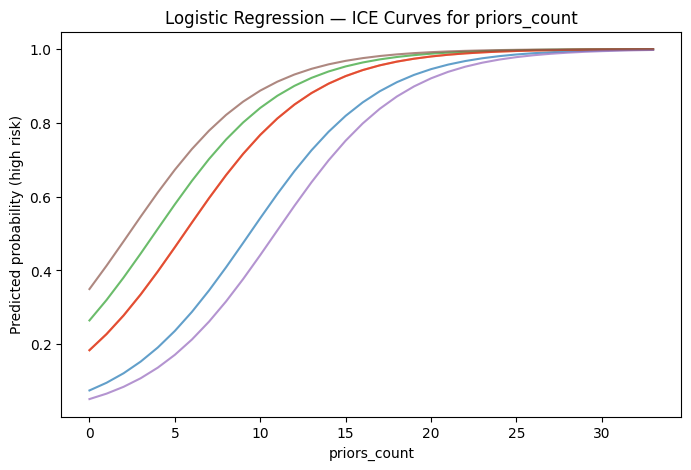

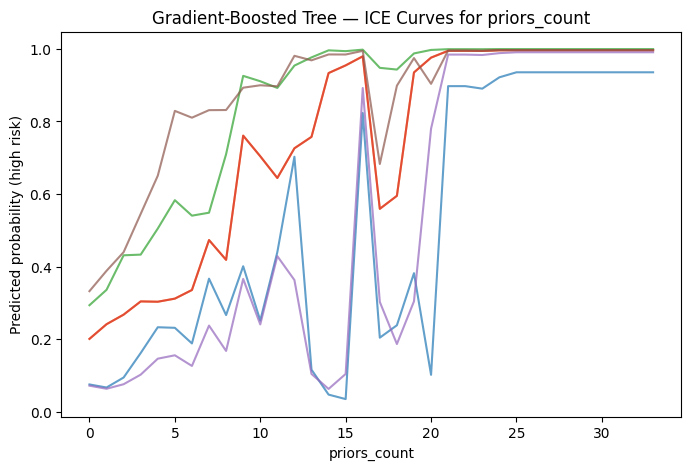


💡 Interpretation of ICE plots:
  • Parallel lines: uniform (monotonic) sensitivity across all individuals
  • Crossing/divergent lines: interaction effects (priors impact depends on other features)
  • Steep slopes: strong sensitivity to priors_count
  • Flat slopes: weak sensitivity (may indicate other features dominate)

--- D.3: Global Sensitivity Index (priors_count) ---
Aggregated measure: variance of mean predictions across priors_count range.

     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count             0.0488          0.2876          0.9992            0.7116   Logistic Regression
priors_count             0.0412          0.2825          0.9802            0.6977 Gradient-Boosted Tree

💡 Interpretation:
  • sensitivity_index: variance of mean scores as feature varies
  • range_mean_score: difference between max and min predicted probabilities
  • Higher range = model is more sensitive to feature variations
  • Us

In [ ]:
# ============================================================================
# PART D: ROBUSTNESS (Stress Testing & Sensitivity Analysis)
# ============================================================================
# Stress tests measure how model predictions respond to adverse or counterfactual scenarios.
# ICE (Individual Conditional Expectation) plots show per-individual sensitivity curves.
# Global sensitivity index aggregates across all individuals.

print("\n" + "="*70)
print("PART D: ROBUSTNESS VIA STRESS TESTING & SENSITIVITY ANALYSIS")
print("="*70)

print("\n--- D.1: Stress Test on priors_count ---")
print("Scenario: Add δ to priors_count, observe mean predicted probability shift.")
print("Measures sensitivity to historical criminogenic factor (prior arrests).\n")

for name, model in models.items():
    print(f"\n{name.upper()}")
    print("-" * 60)
    
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(stress_table.round(4).to_string(index=False))

    print("\n💡 Interpretation:")
    print("  • share_pred_high_risk increases with δ: model increases risk prediction when priors go up")
    print("  • sharp slope (Δshare >> 10% per increment): model heavily weights priors (expected)")
    print("  • flat/absent slope: priors_count may be underutilized (model ignores signal)")
    print("\n✓ What actions are justified:")
    print("   – If slope too steep: priors dominates; risk of perpetuating recidivism cycles")
    print("   – Consider regularization or fairness overlay (e.g., cap contribution of priors)")
    print("   – Compare to LR vs. GBT: tree may be more sensitive to non-linear interactions")

# ICE-style sensitivity plots for priors_count
print("\n\n--- D.2: Individual Conditional Expectation (ICE) Curves ---")
print("Shows predicted probability for each individual as priors_count varies.\n")

priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression — ICE Curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree — ICE Curves for priors_count"
)

print("\n💡 Interpretation of ICE plots:")
print("  • Parallel lines: uniform (monotonic) sensitivity across all individuals")
print("  • Crossing/divergent lines: interaction effects (priors impact depends on other features)")
print("  • Steep slopes: strong sensitivity to priors_count")
print("  • Flat slopes: weak sensitivity (may indicate other features dominate)")

# Global sensitivity index for priors_count
print("\n--- D.3: Global Sensitivity Index (priors_count) ---")
print("Aggregated measure: variance of mean predictions across priors_count range.\n")

lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print(sensitivity_table.round(6).to_string(index=False))

print("\n💡 Interpretation:")
print("  • sensitivity_index: variance of mean scores as feature varies")
print("  • range_mean_score: difference between max and min predicted probabilities")
print("  • Higher range = model is more sensitive to feature variations")
print("  • Useful for: prioritizing which features most impact predictions (policy lever)")

print("\n" + "="*70)

## PART E: SLICE-BASED EVALUATION (Fairness Analysis by Demographic Groups)

In [ ]:
# ============================================================================
# PART E: SLICE-BASED EVALUATION (Fairness Analysis by Demographic Groups)
# ============================================================================
# Slice-based evaluation breaks performance down by demographic subgroups
# (race, gender, age, crime type) to detect disparities.
# 
# Key fairness metrics:
# - Accuracy: overall correctness per group (should be similar across groups)
# - FPR (False Positive Rate): false alarms; high FPR on minorities = bias
# - FNR (False Negative Rate): missed cases; high FNR = under-prediction for group
# - AUC: discrimination power per group (should not diverge wildly)

print("\n" + "="*70)
print("PART E: SLICE-BASED FAIRNESS EVALUATION")
print("="*70)

slice_features = ["race_factor", "gender_factor", "age_factor", "crime_factor"]

for name, model in models.items():
    print(f"\n{name.upper()}")
    print("="*70)
    
    slice_tables = []
    for col in slice_features:
        # Skip if column not in test set
        if col not in X_test.columns:
            continue
        
        result = slice_metrics(model, X_test, y_test, group_col=col)
        if len(result) > 0:
            slice_tables.append(result)
    
    if slice_tables:
        slice_eval = pd.concat(slice_tables, ignore_index=True)
        slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])
        
        print("\nDetailed Slice Metrics:")
        print(slice_eval.round(4).to_string(index=False))

        # Compute disparity statistics
        print("\n--- Fairness Disparity Analysis ---")
        for feature in slice_eval["slice_feature"].unique():
            feature_data = slice_eval[slice_eval["slice_feature"] == feature]
            
            print(f"\n{feature}:")
            accuracy_range = feature_data["accuracy"].max() - feature_data["accuracy"].min()
            fpr_range = feature_data["fpr"].max() - feature_data["fpr"].min()
            fnr_range = feature_data["fnr"].max() - feature_data["fnr"].min()
            auc_range = feature_data["auc"].max() - feature_data["auc"].min()
            
            print(f"  Accuracy range: {accuracy_range:.4f}")
            print(f"  FPR range:      {fpr_range:.4f} (false alarm disparity)")
            print(f"  FNR range:      {fnr_range:.4f} (miss rate disparity)")
            print(f"  AUC range:      {auc_range:.4f}")

        print("\n💡 What each metric tells us:")
        print("  • Accuracy: Overall correctness (should be similar across groups)")
        print("  • AUC: Discrimination power (ability to rank high-risk correctly)")
        print("  • FPR: False positive rate (labeling innocents as 'high risk')")
        print("  • FNR: False negative rate (failing to flag actual recidivists)")
        print("  • positive_rate_pred: % predicted as high-risk (selection rate)")
        print("  • mean_score: average predicted probability per group")

        print("\n⚠️  What disparities mean:")
        print("  • High FPR on minority group: more false alarms → bias in algorithm")
        print("  • High FNR on minority group: under-prediction → systematic under-flagging")
        print("  • Different accuracy: model learns different patterns for different groups")
        print("  • Different mean_score: groups receive systematically different risk scores")

        print("\n✓ What actions are justified:")
        print("   1. If accuracy_range > 0.10: group-specific model tuning may be needed")
        print("   2. If FPR_range > 0.15: audit for bias; consider fairness constraint")
        print("   3. If FNR_range > 0.15: model under-flags certain groups (adjust threshold/threshold per group)")
        print("   4. Publish these metrics: transparency on fairness trade-offs")
        print("   5. Consider: equalized odds (same FPR/FNR across groups)")
        print("   6. Consider: demographic parity (same selection rate across groups)")

print("\n" + "="*70)
print("END OF ANALYSIS")
print("="*70)
print("\n✅ Summary of insights:")
print("   • Distribution Drift (Part A): input/score stability across train/test")
print("   • Generalization (Part B): train/test gap diagnosis + feature importance stability")
print("   • Spurious Correlations (Part C): counterfactual sensitivity to protected attributes")
print("   • Robustness (Part D): stress-test sensitivity curves and global importance")
print("   • Fairness (Part E): group-level performance disparities in accuracy, FPR, FNR")
print("\n📊 Recommended audit checklist:")
print("   ☐ Input drift PSI < 0.25 for all numeric features")
print("   ☐ Train-test AUC gap < 0.03 (generalization OK)")
print("   ☐ Permutation importance stable train vs. test")
print("   ☐ Counterfactual race/gender swap < 0.05 mean shift")
print("   ☐ Priors_count stress test shows expected monotonic increase")
print("   ☐ Slice-based FPR/FNR ranges < 0.15 across all demographic groups")
print("   ☐ No statistically significant performance gap in any slice")
print("="*70)


PART E: SLICE-BASED FAIRNESS EVALUATION

LOGISTIC REGRESSION

Detailed Slice Metrics:
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.387

## Robustness via stress testing and sensitivity analysis

## One compact comparison table for the live session

In [ ]:
# ------------------------------------------------------------
# Compact live-coding summary
# ------------------------------------------------------------
summary_rows = []

# Drift
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))


=== Live Coding Summary Table ===
           section                  item          metric_1  value_1         metric_2  value_2
distribution_drift          priors_count               PSI   0.0104        KS_pvalue   0.2113
distribution_drift        two_year_recid               PSI   0.0008        KS_pvalue   0.9862
distribution_drift      encoded_features             MMD^2  -0.0003                       NaN
    generalization   Logistic Regression           AUC_gap  -0.0037     Accuracy_gap   0.0017
    generalization Gradient-Boosted Tree           AUC_gap   0.0245     Accuracy_gap   0.0250
        robustness   Logistic Regression Sensitivity_index   0.0488 Range_mean_score   0.7116
        robustness Gradient-Boosted Tree Sensitivity_index   0.0412 Range_mean_score   0.6977
